In [1]:
# Import relevant libraries here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')


#### Name:   Samina Saadia (s.saadia@gmail.com) - Machine Learning with Life Expectancy Dataset

### Submission Instructions:

### Dataset Description:

- **Life_Expectancy:** Average life expectancy at birth in years. <br><br>
- **Adult_Mortality:** Adult mortality between 15-60 years per 1000 population. <br><br>
- **Infant_Deaths:**: Infant mortality between birth and 11 months per 1000 population. <br><br>
- **Alcohol**: Alcohol consumption in litres of pure alcohol per capita for 15+ years old. <br><br>
- **Hepatitis_B:** % coverage of Hepatitis B (HepB3) immunization among 1 year olds. <br><br>
- **Measles:** Average number of recorded Measles cases. <br><br>
- **BMI:** Average recorded BMI. <br><br>
- **Under-five_Deaths:** Under 5 mortality rate per 1000 live births. <br><br>
- **Polio:** % coverage of Polio (Pol3) immunization among 1 year olds. <br><br>
- **Diphtheria:** % coverage of DTP3 immunization among 1 year olds. <br><br>
- **HIV/AIDS:** Incidents of HIV/AIDS per 1000 population aged 15-49. <br><br>
- **Thinness_10-19_Years:** Prevalence (%) of thinness (BMI < -2) among 10-19 years. <br><br>
- **Thinness_5-9_Years:** Prevalence (%) of thinness (BMI < -2) among 5-19 years. <br><br>
- **GDP:** GDP per capita in USD. <br><br>
- **Population:** Total population. <br><br>
- **Schooling:** Average years that people aged 25+ spent in formal education.




### Objective:

My goal in this assignment is to utilize Machine Learning techniques learned to predict average `Life_Expectancy` of a country. In this assignment, I will be training multiple Machine Learning models and analyzing tradeoff and evaluating results.

##### Import the dataset

In [2]:

# Import dataset
from google.colab import drive
drive.mount('/content/drive',force_remount = True)
path = "/content/drive/MyDrive/ColabNotebooks/DA4/data.csv"
df = pd.read_csv(path)

print(df.shape)
df.head()
#df.info()
#round(df.describe(),2)
#df.isnull().sum()


Mounted at /content/drive
(2938, 19)


,Country,Year,Status,Life_Expectancy,Adult_Mortality,Infant_Deaths,Alcohol,Hepatitis_B,Measles,BMI,Under-five_Deaths,Polio,Diphtheria,HIV/AIDS,GDP,Population,Thinness_10-19_Years,Thinness_5-9_Years,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,65.0,1154,19.1,83,6.0,65.0,0.1,584.259210,33736494.0,17.2,17.3,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,62.0,492,18.6,86,58.0,62.0,0.1,612.696514,327582.0,17.5,17.5,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,64.0,430,18.1,89,62.0,64.0,0.1,631.744976,31731688.0,17.7,17.7,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,67.0,2787,17.6,93,67.0,67.0,0.1,669.959000,3696958.0,17.9,18.0,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,68.0,3013,17.2,97,68.0,68.0,0.1,63.537231,2978599.0,18.2,18.2,9.5


<b>Question :</b> Write (as a comment) your prediction about which attributes from the dataset that should effect <em>Life Expectancy</em> of a country the most. This is an open-ended question and does not have a correct answer.  

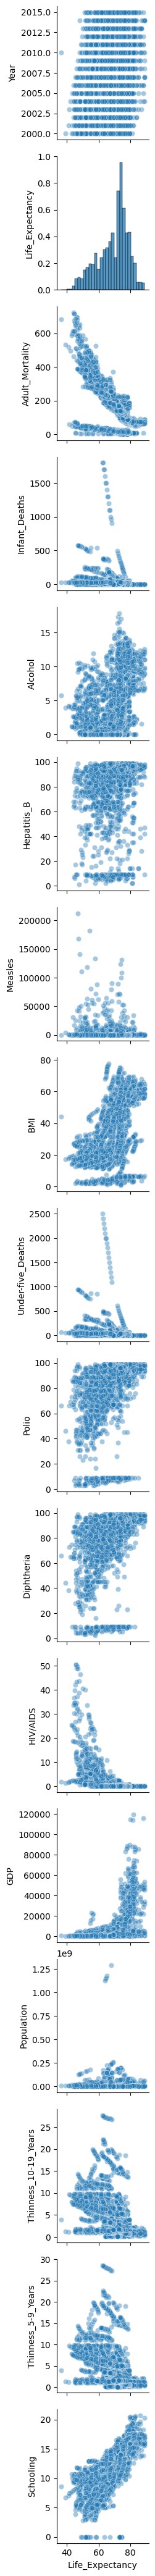

In [3]:

"""
To check which attributes from the dataset that should effect Life Expectancy of a country the most
we need to draw a correlation heatmap
"""
# selecting number or float datatypes

numeric_cols = df.select_dtypes(include=[np.number])

df_correlation = numeric_cols.corr()


x_variables = ['Life_Expectancy'] # Corrected: Changed to 'Life_Expectancy' with correct capitalization
y_variables = numeric_cols.columns

sns.pairplot(numeric_cols,x_vars = x_variables, y_vars=y_variables ,kind='scatter', plot_kws=  {'alpha' : 0.4})


**Attributes Effecting the Life Expectancy the Most**

The plots show the strong positive correlation of life expectancy with:

**Schooling, GDP, Hepatitis_B, Polio and Diphtheria**.

These attributes have the highest absolute correlation values. **More years of formal education** means more awareness regarding health issues and factors contributing to life expectancy. Families having better education try to complete the **vaccinations** of their children which definitely helps in getting better life span.

Another important factor contributing in life expectancy is **better financial conditions**. Families who can afford to give better facilities and livelihood to their children, add in better life expectancy of their families.

According to dataset BMI is also affecting the life expectancy moderately.

Attributes having strong negative correlation are: adult_mortality, infant_deaths, under_five_deaths, hiv_aids, thinness_10_19_years and thinness_5_9_years

Attributes having strong positive correlation are likely to be the strongest predictors of "average life expectancy prediction model".

# Data Cleaning:

<b>Question :</b> Explore and clean the data to make predictions more accurate.

*Hints:*
<li>You need to deal with missing data. You are not allowed simply drop all rows with missing data.</li>
<li>Filter out (drop) missing values from <em>Life_Expectancy</em>, <em>Population</em>, <em>Alcohol</em> columns. </li>
<li>For the remaining columns, come up with an approrpiate strategy to deal with missing values.</li>
<li>Remove non-numerical data.</li>

In [4]:
# Write code here

df.columns = (df.columns
              .str.replace(r"[ /-]", "_", regex=True)
              .str.lower())                 #converting '/' and '-'  to '_' and converting all columns names to lower

cols_to_lower = ['country','status']                # converting all categorical rows to lower case
for col in cols_to_lower:
    df[col] = df[col].str.lower()

df = df.dropna(subset=['life_expectancy','population','alcohol'])               # drop missing rows in life_expectancy,population and alcohol
print(df.isnull().sum())

#print(df.head())

country                   0
year                      0
status                    0
life_expectancy           0
adult_mortality           0
infant_deaths             0
alcohol                   0
hepatitis_b             459
measles                   0
bmi                      15
under_five_deaths         0
polio                     7
diphtheria                7
hiv_aids                  0
gdp                      12
population                0
thinness_10_19_years     15
thinness_5_9_years       15
schooling                 0
dtype: int64


Percentage of missing data in 'hepatitis_b': 21.56%
Percentage of missing data in 'bmi': 0.70%
Percentage of missing data in 'polio': 0.33%
Percentage of missing data in 'diphtheria': 0.33%
Percentage of missing data in 'gdp': 0.56%
Percentage of missing data in 'thinness_10_19_years': 0.70%
Percentage of missing data in 'thinness_5_9_years': 0.70%


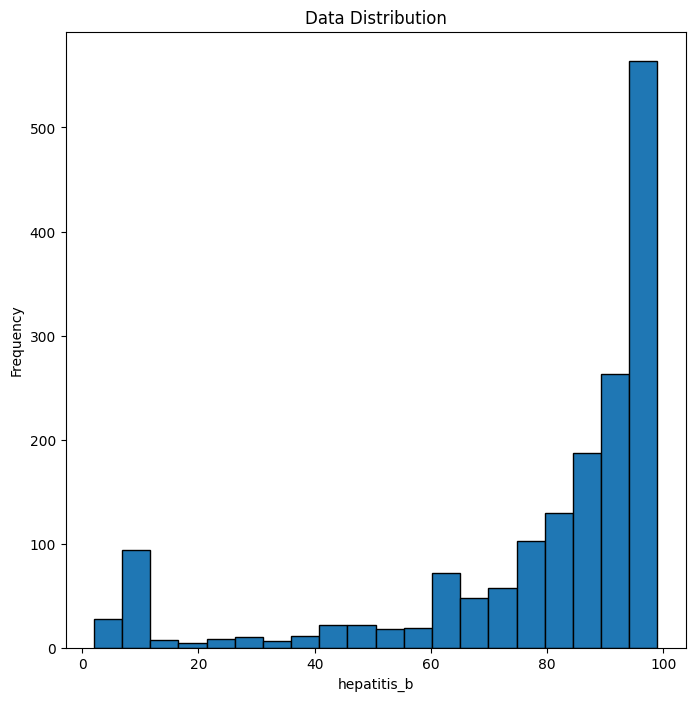

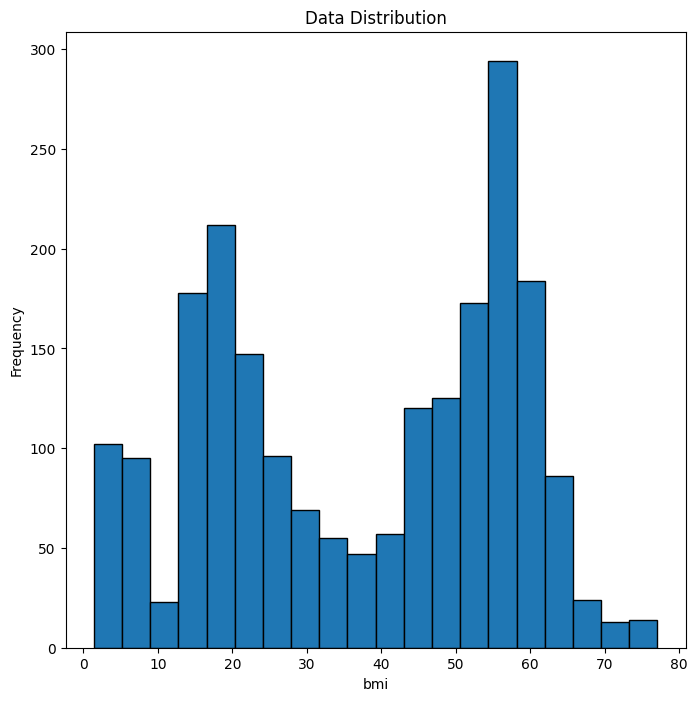

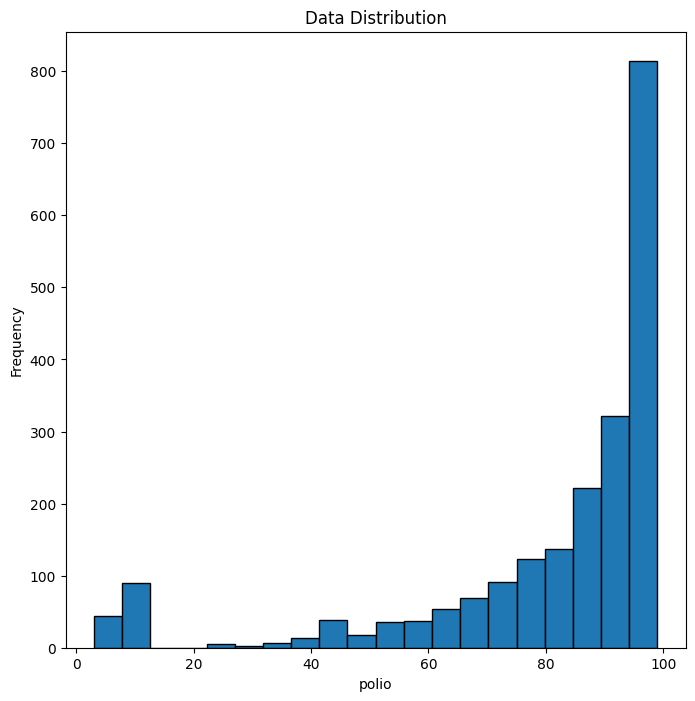

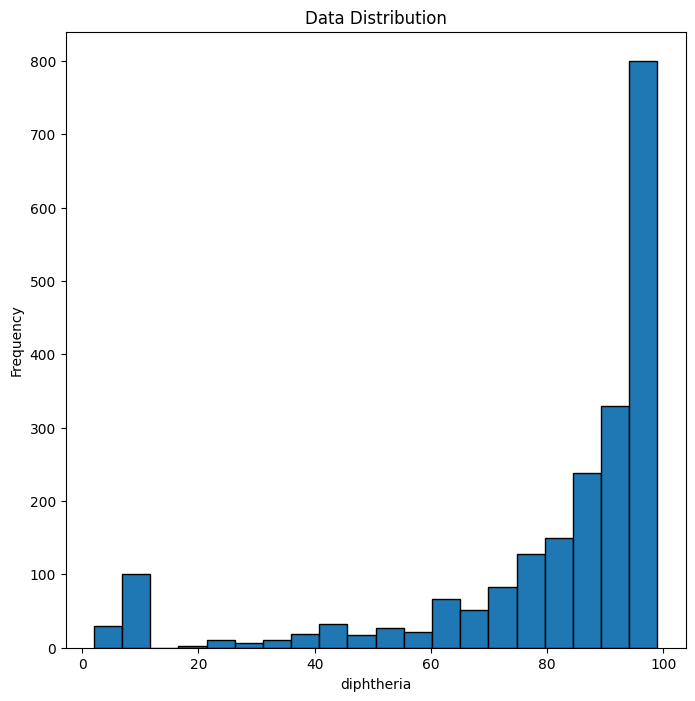

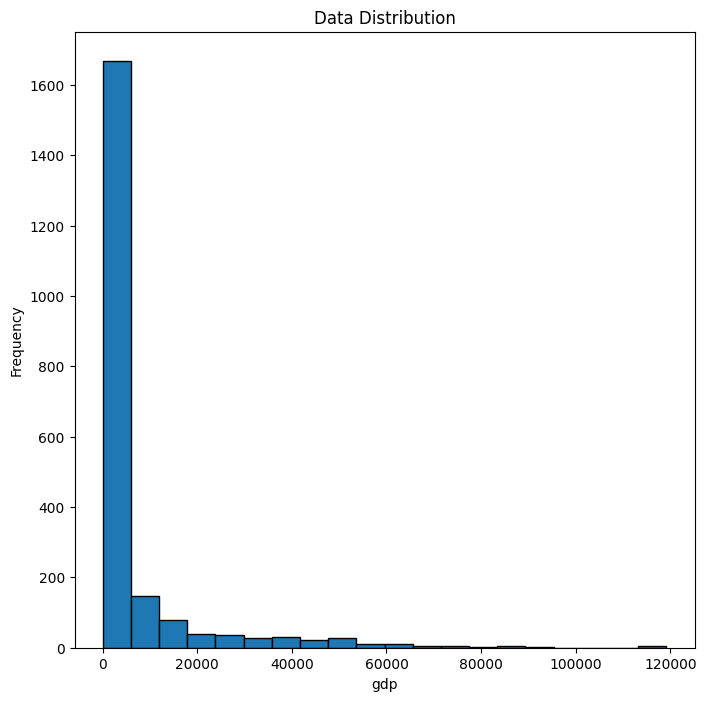

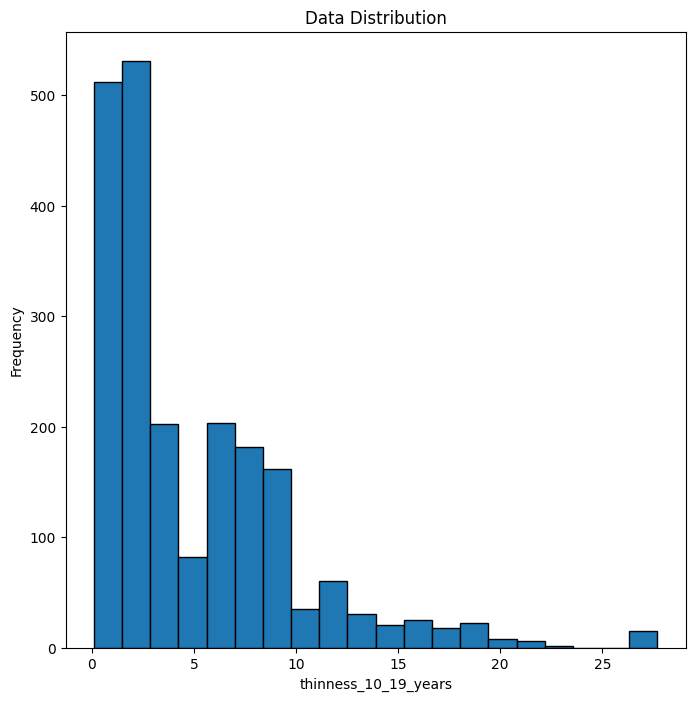

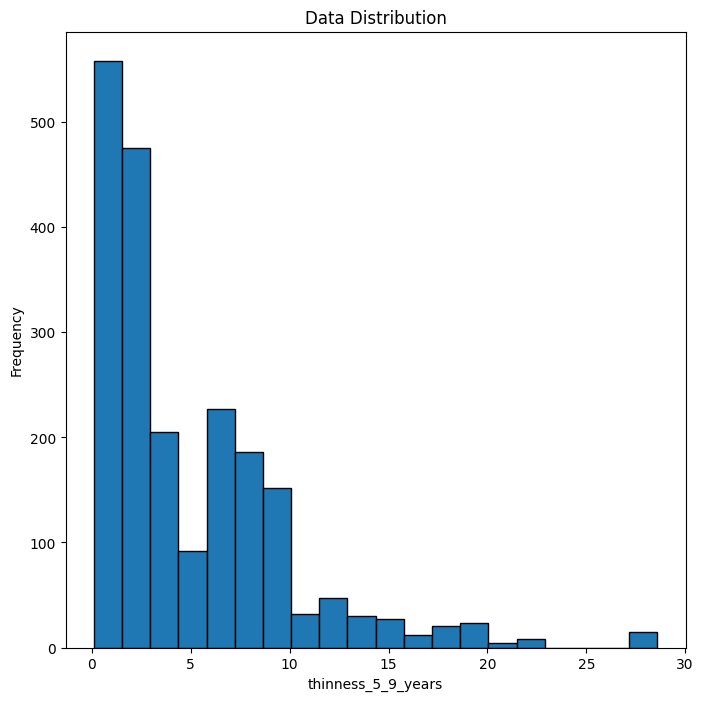

In [5]:
# Now we have 7 columns with missing data. we will find percentage of missing data in columns

missing_data_cols = ['hepatitis_b','bmi','polio','diphtheria','gdp','thinness_10_19_years','thinness_5_9_years']

# % of missing data in 'missing_data_cols'
for col in missing_data_cols:
    missing_count = df[col].isnull().sum()
    total_count = len(df)
    missing_percentage = (missing_count / total_count) * 100
    print(f"Percentage of missing data in '{col}': {missing_percentage:.2f}%")

# as second check plotting histogram of above 'missing_data_cols' using loop
for col in missing_data_cols:
    plt.figure(figsize=(8,8))
    plt.hist(df[col],bins = 20,edgecolor = 'black')
    plt.title(f"Data Distribution")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


**Explanation:**

**Histograms** showing skewness of data. Data varies for developing and non developing countries so there is skewness present in data.

As **Solution** to the missingness of such data, we can use median of values for each country level.

**Imputations**. we can impute using country level information.

In [6]:
# Imputing for missing data columns

for col in missing_data_cols:
    df[col] = (df.groupby('country')[col].transform(lambda x: x.fillna(x.median())).fillna(df[col].median()))

print(df.isnull().sum())

country                 0
year                    0
status                  0
life_expectancy         0
adult_mortality         0
infant_deaths           0
alcohol                 0
hepatitis_b             0
measles                 0
bmi                     0
under_five_deaths       0
polio                   0
diphtheria              0
hiv_aids                0
gdp                     0
population              0
thinness_10_19_years    0
thinness_5_9_years      0
schooling               0
dtype: int64


<b>Question :</b> Draw a correlation heatmap for the resulting dataframe.


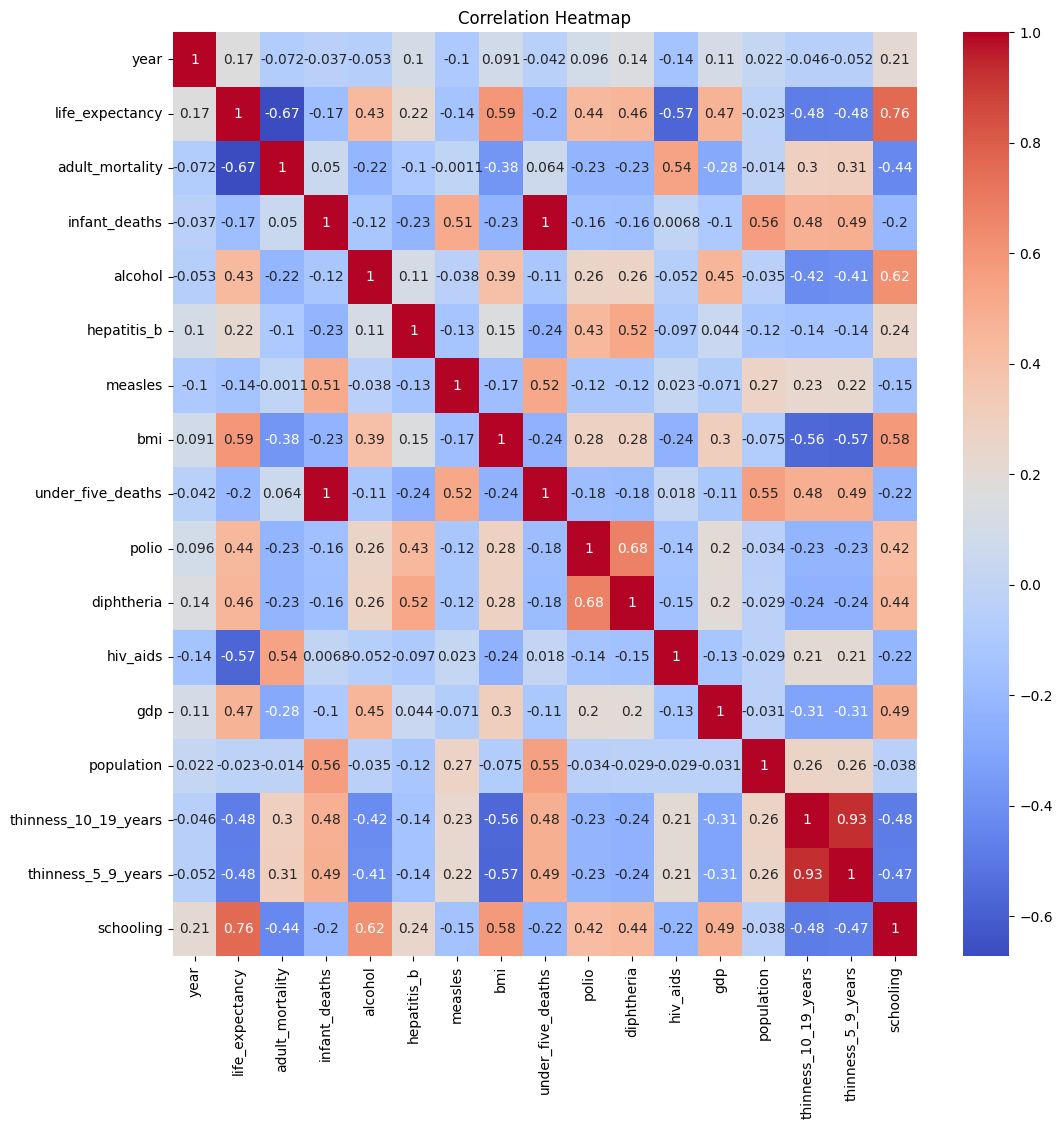

In [7]:
# Write code here
# correlation heat map of dataset

numeric_cols = df.select_dtypes(include=[np.number])

df_correlation = numeric_cols.corr()

#print(df_correlation)

plt.figure(figsize=(12,12))
sns.heatmap(df_correlation,cmap='coolwarm',annot=True)

plt.title("Correlation Heatmap")

plt.show()


<b>Question 2 (b):</b> Explain any interesting correlations that you observe. Do you think `Population` column should be dropped because it has a low association with `Life_Expectancy`? Why or why not?

*This is an open ended question, there is no correct answer*



**Interesting Correlations**


Different relationships observed from correlation heatmap are:

**Schooling vs Life_Expectancy**

This is most interesting strong positive correlation  in given dataset. It means more years of schooling, higher is the life expectancy. Education improves the awareness related to health problems and solutions. Awareness related to what health care facilities are available from governments and what kind of vaccinations are important.
GDP vs Life_Expectancy
This relationship has strong to moderate correlation. The richer countries can invest more in health care, vaccinations and sanitation kind of facilities, which ultimately improves the over all life expectancy in the country.

**Vaccinations vs Life_Expectancy**

Immunizations increase the health quality.  Vaccinations prevent deadly diseases I children and decrease the mortality at young age. As a result life expectancy increases.

**BMI vs Life_Expectancy**

It has moderate positive correlation. Not strong one but somehow better BMI shows better health conditions. Extremely low BMI shows under nutrition and poor health in population. Generally people from poor countries have lower BMI. Which can lead to lower life_expectancy

**Adult_Mortality vs Life_Expectancy**

Countries where adult mortality is higher, life expectancy is lower in those countries. This can be due to poor health and living conditions.  This one of the strongest negative correlations.
Infant_Deaths/ Inder_Five_Deaths  vs  Life_Expectancy
Higher infants and toddlers deaths mean lower life expectancy. This shows poor economic, health and living conditions in a country.

**HIV/AIDS vs Life_Expectancy**

It has strong negative correaltion with life expectancy. HIV/AIDS is a major cause of pre mature death rates in poor and middle income countries.

**Thinness_10_19_Years/ Thinness_5_9_Years vs Life_Expectancy**

Thinness reflects male nutrition in children which leads to low life expectancy. This also shows poor economic and health care services and overall poor development of
 Countries.

**Population Column Should be Dropped or Not:**

Population has **"-0.023 correlation"** with life_expectancy. It has very low correlation with life expectancy. Therefore, conceptually it make sense if we drop the column as population of a country can not determine if people will live longer life or shorter. This column can not help directly in predicting the life expectancy in our model. This column has no direct causal effect on life_expectancy.

**BUt**

With population column we can determine how countries can provide better health, education and other services. Countries with bigger population and lower GDP stuggle to provide better services to their people. Therefore indirectly this can help in finding life expectancy of countries. This is the reason we can keep this column in our dataset.


## Splitting Dataset:

<b>Question :</b> <br>

a) Create a 70-30 train-test split. Assign your train data to `train_df` and your test data to `test_df`

b) Divide `train_df` into input and output variables (train_X and train_y). Divide `test_df` into input and output variables (test_X and test_y).


In [8]:
# Write code here
train_df, test_df = train_test_split(df, test_size=0.3, random_state=42)    #splitting data into 30/70 test/train data split

# dividing train_df into train_X and train_y

train_X = train_df.drop('life_expectancy', axis=1)
train_y = train_df['life_expectancy']

#dividing test_df into test_x and test_y  variable
test_X = test_df.drop('life_expectancy', axis=1)
test_y = test_df['life_expectancy']

print(train_X.shape)
print(train_y.shape)
print(test_X.shape)
print(test_y.shape)

(1490, 18)
(1490,)
(639, 18)
(639,)


## Linear Regression:

**Question :** Use Statsmodels to train a multiple linear regression model on the data. Note that the value we are aiming to predict is `Life expectancy`, and we will be using Ordinary Least Squares. Print out the summary of your model.

*Note: Do not forget to add a constant bias variable.*

In [10]:
# Write code here

#drop non numerical columns
train_X = train_X.select_dtypes(include=[np.number])

train_X_with_constant = sm.add_constant(train_X)
model = sm.OLS(train_y, train_X_with_constant)
results = model.fit()
print(results.summary())


                            OLS Regression Results                            
Dep. Variable:        life_expectancy   R-squared:                       0.840
Model:                            OLS   Adj. R-squared:                  0.839
Method:                 Least Squares   F-statistic:                     484.4
Date:                Fri, 10 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:20:27   Log-Likelihood:                -4167.8
No. Observations:                1490   AIC:                             8370.
Df Residuals:                    1473   BIC:                             8460.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  142.3071 

**Question :** Comment on the statistical significance of your variables in predicting life expectancy.

**Variables Description in Linear Regression Model**
Resulted statistics indicate that overall regression model is highly statistically significant.

**F-Statistics (484.4)**. This value indicates that variation in the dependent variable explained by model is greater than random error. This indicates that independent variables in model collectively provide a good fit for data better than models with no independent variables.

**Prob (F-Statistics) (0.00)**. This is p-value for overall f-test. A value of 0.00, which is less than common significance level 0.05 means there is negligible probability that results occurred by random chance alone.

**R-squared & adjusted R-squared:**
These values state that independent variables chosen for the model effectively contribute to explaining the variance in outcome. Overall, these are positive values for OLS regression.

**R-squared (0.840)** indicates that 84.0% variation in dependent variable(response) can be explained by independent variable (predictor). This is generally considered a strong fit.

**Adjusted R-squared (0.839)**.  This is modified r-squared which accounts for number of predictions in model.
R-squared value can increase with the number of variables even if those are not relevant and significant but adjusted R-squared increase only if the variables or predictors are relevant and significant and model does not suffer from including many unnecessary variables.


**Log-likelihood, AIC & BIC**
Model’s log-likelihood is mostly useful when compared with other models. It itself does not tell “good” or “bad”. But if we add useful variables then log-likelihood increases (less negative), means values indicate better fit. And if we add noise variables log-likelihood barely moves or gets worse.

**Statistically Significant Predictors (at 5% level)**

These variables have values p < 0.05, so are statistically significant in predicting life expectancy.

**Adult_mortality: (coef = -0.0173, p=0.000)**  Higher adult mortality is strongly associated with lower life expectancy.

**Infant_deaths: (coef = +0.0952, p=0.000)** Statistically significant but (+) sign is counter intuitive. In real higher death rate should reduce the life expectancy. This wrong sign effect is may be due to “multicollinearity” with “under_five_deaths” and other health variables.

(**Multicollinearity** is a phenomenon in statistical modeling where two or more independent variables are highly corelated, making it difficult to determine the individual effect of each variable on dependent variable.)


**Alcohol: (coef = -0.0827, p = 0.022)**. Higher alcohol consumption is associated with slightly lower life expectancy.

**BMI: (coef = +0.0583, p = 0.000)** Higher average BMI is associated with higher life expectancy, considering undernutrition being harmful.

**Under_five_deaths: (coef = -0.0693, 0.000)** Its obvious more under five deaths, lower the life expectancy.

**Polio: (coef = +0.0181, p = 0.003)** Higher the polio vaccine coverage, higher is the life expectancy.

**Diphtheria: (coef = +0.0392, p = 0.000)** Higher diphtheria vaccine coverage, higher life expectancy.

**Hiv_aids: (coef = -0.4768, p = 0.000)** Very strong negative effect. Higher HIV/AIDS sharply reduces life expectancy.

**gdp: (coef ~ 0.000072, p=0.000)** higher gdp is associated with higher life expectancy. Effect peer unit is small but gdp values are higher.

**schooling: (coef = =1.2163, p=0.000)** one extra year of average schooling is associated with about 1.2 extra year of life expectancy. Very strong and highly significant predictor.


**Not Statistically Significant (at 5% level), Predictors:**
These predictors have p>= 0.05, so there is no strong evidence (at 5% level).
These variables are:

**year: (p = 0.083)** borderline at 10% but not at 5%

**hepatitis_b:** (p = 0.076)just marginal not significant at 5%

**measels: (p = 0.069)** Its also borderline

**population: (p = 0.234)** not significant

**thinness_10_19_years: (p = 0.267)** not significant

**thinness_5_9_years: (p = 0.993)** not significant



**Conclusion:**

We can say that several health and developmental indicators like schooling, gdp, hiv/aids, adult and under_five mortality, vaccination coverage and bmi are statistically significant predictors of life expectancy. On the other hand, population and thinness variables are not significant.

Results show that we can reject null hypothesis which states that all regression coefficients are equal to zero and model is not fit.

Results show there is strong evidence that at least one independent variable has significant linear relationship with dependent variable and that the model on whole is meaningful and useful for predictions.



**Question :** Plot a graph of
- your 3 most significant explanatory variables on the x axis and
- the predicted variable `Life_expectancy` on the y axis

Note: You are expected to plot all three explanatory variables on the same graph. You can use any EDA technique as long as you can ascertain a trend between the variables (if any).

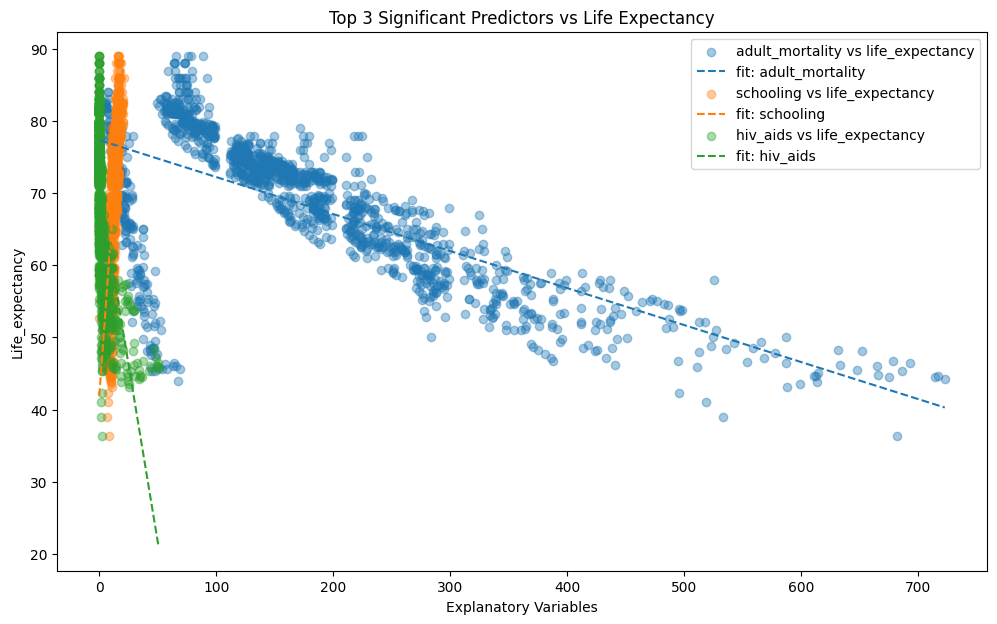

In [11]:

significant_vars = ['adult_mortality', 'schooling', 'hiv_aids']

plt.figure(figsize=(12, 7))

for var in significant_vars:
  x = train_X[var].values
  y = train_y.values

  plt.scatter(x, y, alpha=0.4, label=f"{var} vs life_expectancy")

  slope, intercept = np.polyfit(x, y, 1)

  x_vars = np.linspace(x.min(), x.max(), 200)
  y_vars = slope * x_vars + intercept
  plt.plot(x_vars,y_vars, linestyle='--', label=f"fit: {var}")

plt.title("Top 3 Significant Predictors vs Life Expectancy")
plt.xlabel("Explanatory Variables")
plt.ylabel('Life_expectancy')
plt.legend()
plt.show()


**Question :** Considering the plot you made in Question 6, was a linear model a good choice? Why or why not?

A linear model is a reasonable first choice but it’s not perfect.

From the graph of [schooling , adult_mortality, hiv_aids] vs life_expectancy we can conclude:

**Schooling vs Life Expectancy:**
The graph shows a clear upward trend. As number of school years increases, life expectancy increases. This creates **approximately straight line**; therefore, there is **roughly linear relationship** as it shows almost sharp increase in life expectancy as school years increase.  

**HIV/AIDS vs Life Expectancy:**
We can see a clear upward trend. Higher HIV/AIDS deaths mean lower life expectancy. Relationships look again **roughly linear** as there is sharp decrease in life expectancy vs HIV/AIDS.  Therefore, a straight line captures the main effect quite well.

**Adult Mortality vs Life Expectancy:**
We see higher adult mortality rate associated with lower life expectancy. Almost a straight line is present in relationship.

Since there is no obvious curve present in graph, it just scattered around a clear increasing or decreasing trend. This supports the use of linear models as interpretable choice.

**Linear model is acceptable but not perfect:**

There are scatters around the curve, which show some spread around the fitted lines and potential non-linear effects at extreme values, therefore, **relationship isn’t perfectly linear**. Model has collinearity which doesn’t break linearity, but it does mean model has some limitations. More flexible models could be explored in more advanced analysis.  


**Question **: Implement the function `RMSE` that takes as an input
- The output column in `test_df` and
- The *predicted* output column of the `test_df`.

The output of this function should be the Root Mean Square Error (RMSE) of the prediction. You must calculate this from scratch (and you are not allowed to use loops).

Use this function to print out the RMSE of your Statsmodels OLS model.

In [12]:

def RMSE(test_y, pred_y):
    mse = np.mean((test_y - pred_y) ** 2)
    rmse = np.sqrt(mse)
    return rmse

test_X_with_constant = sm.add_constant(test_X , has_constant='add')
needed_cols = results.params.index
test_X_aligned = test_X_with_constant.reindex(columns=needed_cols, fill_value=0)

#test_pred = results.predict(test_X_with_constant)
test_pred = results.predict(test_X_aligned)

rmse = RMSE(test_y, test_pred)
print("RSME : " ,round(rmse,6))

print("\nTrue Values")
print(test_y.head())

print("\nPredicted Values")
print(round(test_pred.head(),1))

#print(results.params.index)
#print(test_X_with_constant.columns)



RSME :  4.14796

True Values
395     72.2
2692    72.0
2299    54.0
1698    74.8
2712    63.8
Name: life_expectancy, dtype: float64

Predicted Values
395     73.2
2692    72.1
2299    67.4
1698    72.2
2712    55.3
dtype: float64


**RMSE = 4.14796** is a very good value for life_expectancy dataset. Our life expectancy values range from 36.3 to 89. and RMSE value means our model predicts +-4 years of true value. This shows a strong performance of the model.

Comparison of true and predicted values show that model predicts well for typical countries but for countries with extreme health conditions, very low GDP and unusual mortality rates it shows larger errors. This is expected behaviour of OLS model.

**Question 9:** In class you studied this formula to find the optimal parameters in a linear model:

$\theta = (X^{T}X)^{-1}X^{T}y$

Write a function to implement this formula from scratch. Compare the parameters you get from this formula to those generated by Statsmodel (as a comment) by comparing the RMSE (of the test data). Explain any difference between the optimal and the OLS model.

**Opimal Parameters :**

In a linear regression model **coefficients and Θ** are the optimal parameters. Above provided formula is known as **"Normal Equation"** which is direct closed-form solution for finding the optimal paframeters. This formula **"minimizes"** the Ordinalry Least Squares **(OLS) cost function**.

In [ ]:
# calculating optimal parameters using nortmal equation

def optimal_parameters(X, y):

  X_transpose = X.T
  X_transpose_X = np.dot(X_transpose, X)
  X_transpose_X_inv = np.linalg.inv(X_transpose_X)

  x_transpose_y = np.dot(X_transpose, y)
  theta = np.dot(X_transpose_X_inv, x_transpose_y)
  return theta

# calling theta in training data
X_train = train_X_with_constant.values
y_train = train_y.values
Θ = optimal_parameters(X_train, y_train)
#print(Θ)

#putting back in series to get same index as columns
theta_series = pd.Series(Θ, index = train_X_with_constant.columns)

print("Comparison of Raw Parameters")
print(pd.concat([results.params, theta_series], axis=1, keys=['StatsModels', 'NormalEquation']))

# adding constant(slope) to test X
test_X_const = sm.add_constant(test_X, has_constant= 'add')
test_X_aligend = test_X_const.reindex(columns=needed_cols, fill_value=0)

# predictions using normal equation theta
test_pred_normal = np.dot(test_X_aligend.values, Θ)
X_test_normal = test_X_aligend.values

#getting predictions
test_pred_ols = results.predict(test_X_aligned)
rmse_ols = RMSE(test_y, test_pred_ols)

#Calculate RMSE for normal equation theta
rmse_normal = RMSE(test_y, test_pred_normal)


print("\n Printing both RMSE Values of Stats OLS Model & Theta, Normal Equation")

print("\n RMSE (Statsmodels OLS):     ", rmse_ols)
print("\n RMSE (Normal equation θ):   ", rmse_normal)


Comparison of Raw Parameters
                       StatsModels  NormalEquation
const                 1.423071e+02    1.423071e+02
year                 -4.479588e-02   -4.479588e-02
adult_mortality      -1.729038e-02   -1.729038e-02
infant_deaths         9.520094e-02    9.520094e-02
alcohol              -8.274407e-02   -8.274407e-02
hepatitis_b          -8.710506e-03   -8.710506e-03
measles              -2.081850e-05   -2.081850e-05
bmi                   5.832495e-02    5.832495e-02
under_five_deaths    -6.925048e-02   -6.925048e-02
polio                 1.813488e-02    1.813488e-02
diphtheria            3.924292e-02    3.924292e-02
hiv_aids             -4.767759e-01   -4.767759e-01
gdp                   7.230708e-05    7.230708e-05
population           -2.449224e-09   -2.449224e-09
thinness_10_19_years -7.379401e-02   -7.379401e-02
thinness_5_9_years   -5.478305e-04   -5.478305e-04
schooling             1.216348e+00    1.216348e+00

 Printing both RMSE Values of Stats OLS Model & Thet

**Comment**

RMSE obtained from-form solution is **almost identical** to the RMSE obtained from statsmodels OLS. Comparison of raw parameters and RMSE is printed for varification. We can say that parameters obtained from normal equation and statsmodel are effectively **almost the same solution to the linear regression model**.

##### Regularized Regression:

**Question :** Use sklearn to perform Ridge regression on the data. Evaluate Ridge regression for a range of $\alpha$ values to find the optimal $\alpha$. Report the MSE of the model for the optimal $\alpha$ on the test set.

**Ridge Regression**

Ridge Regression is a regularization technique that is used to address **issues** like **overfittting**, **multicolenearity** or **many predictors**. It works by adding the penalty to the complexity of the model which stabilizes coefficients estimatesand improved model's performance on unseen data.

**How it Works:**

Standard linear regression or OLS finds the coefficients that minimizes the sum of squared errors between actual and predicted values. on the other hansd Ridge regression works **by minimizing a modified objective function**. This function is:

### Minimize : (Sum of Squared Residuals) + $\lambda$\.  * (Sum of Squared Coefficients)

**L2 Regularization :** The second term $\lambda$\.  * (Sum of Squared Coefficients) is the L2 penalty. It penalizes the large coefficients by adding sum of squared magnitude to the cost function.

**Coefficient Shrinkage:** This penalty forces the model's coefficients to be smaller or closer to zero This shrinkage effect reduces the impact of any single variable. or we can say reducing the variance.

**Lambda $\lambda$\. Parameters:** In scikit-learn lambda is a **tuning hyperparameter** that controls the strength of penalty.

If $\lambda$\. = 0 ridge regression produces the same results as standard OLS linear regression.

If $\lambda$\. is very large, the coefficients will approach to zero presenting very simple or biased model.

Optimal  $\lambda$\. is usually found using techniques like cross-validation to balance the bias-vairance tradeoff.

Its **important**  to standardize or normalize the features before applying ridge regression becuase penalty is based on magnitude of coefficients and features with lage scale can disappropriately effect the penalty.   



In [ ]:
# Write code here

#sk-learn's ridge model needs numeric input
train_X_numeric = train_X.select_dtypes(include=[np.number])
test_X_numeric = test_X.select_dtypes(include=[np.number])

# define range for lambda values
lambdas = np.logspace(-4, 4, 100)

best_alpha = None
min_mse = float('inf')

for alpha in lambdas:
  ridge_model = Ridge(alpha=alpha)
  ridge_model.fit(train_X_numeric, train_y)
  pred_y = ridge_model.predict(test_X_numeric)
  ridge_mse = mean_squared_error(test_y, pred_y)


  if ridge_mse < min_mse:
    min_mse = ridge_mse
    best_alpha = alpha

    print("\n Ridge Optimal Alpha", best_alpha)

    print("MSE with Ridge Optimal Alpha: ", min_mse)
    ridge_rmse = RMSE(test_y, pred_y)

    print("RMSE with Ridge Optimal Alpha: ", ridge_rmse)

rmse_ols = RMSE(test_y, test_pred)

mse_ols = rmse_ols ** 2
print("\n OLS MSE :",mse_ols )


 Ridge Optimal Alpha 0.0001
MSE with Ridge Optimal Alpha:  17.205569950072178
RMSE with Ridge Optimal Alpha:  4.147959733419815

 OLS MSE : 17.20556993108671


# Report:
We performed **Ridge Regression** over a range of alpha values For each alpha vlaue we trained the model over training data and obtained Mean Square Error (MSE) on test data. Using **aplha = 0.0001** we obtained **MSE: 17.205569950072178**.
In **OLS model** we got

**MSE: 17.20556993108671**

Ridge Regression's MSE at alpha 0.0001 is 17.21 which is slightly less than MSE of OLS model. It indicates that **ridge regression slightly improved test performance as compared to linear regression' OLS mode**l. This optimal MSE could be the effect of reduced overfitting because of regularization. Regularization also handles the multicolinearity among predictors.

**Ridge shrinks the coefficients and can improve generalization specially when predictors are highly correlated.**

#**Question :**# As the value of $\alpha$ increases, you will notice the the weights of the model parameters will start to change. Plot the values of all the weights against $\log(\alpha$) on a single figure. Describe what you see.

**Effect of Vlaue of alpha in ridge regression:**

In Ridge Resgression **as the value of alpha increases the complexity of model decreases** due to penalty applied to the model parameters. As result the weights of model parameters will shrink, change and move closer to zero. Due to Ridge Regression  **L2 penalty is applied** which adds sum of squared coefficient values multiply by tuning parameter (lambda). **Due to Ridge regression regularization increases which causes increase in bias and decrease in variance**. this how ridge resgression solves the overfitting problem in model.

When **Alpha = 0:** ridge regression becomes standard linear regression and coefficients are not regularized.

**Samll Alpha:** The penalty is small and weights change only slightly from their linear regression values.

**Increasing Alpha:** Regularization effect becomes stronger causing the weights to shrink more and move closer to zero.

**Very Large Alpha:** The penalty becomes dominenet, causing the pushed to be closer to zero. This phenominon can over simplify the model and this can lead to underfitting the model.

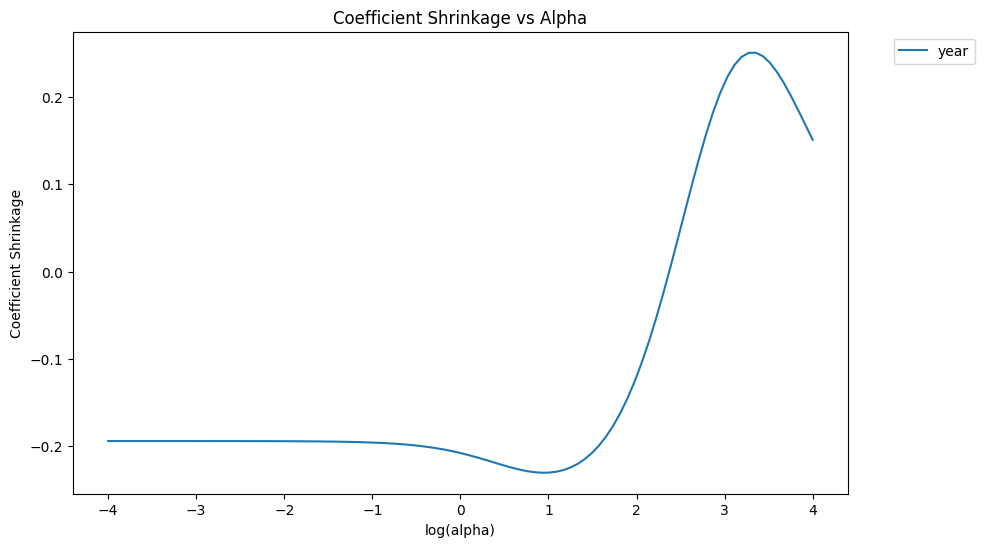

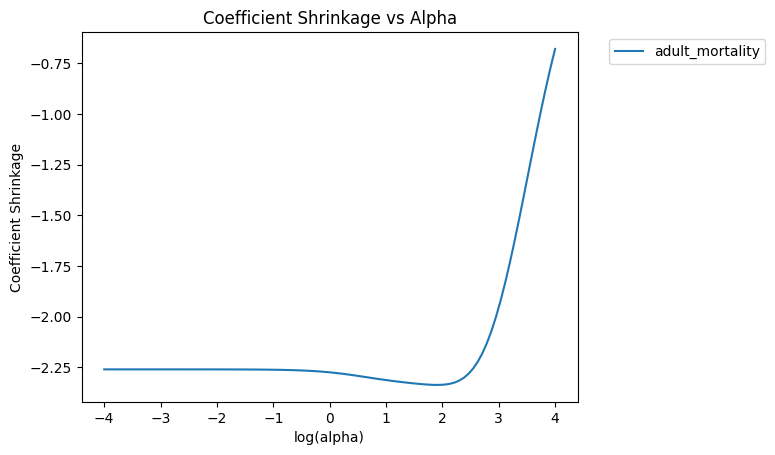

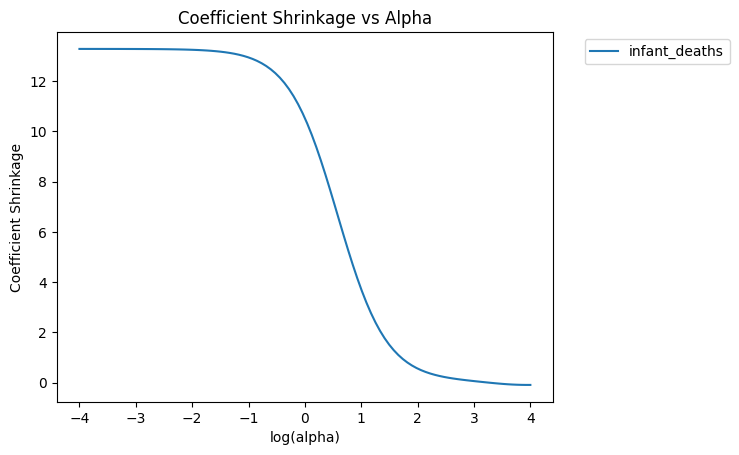

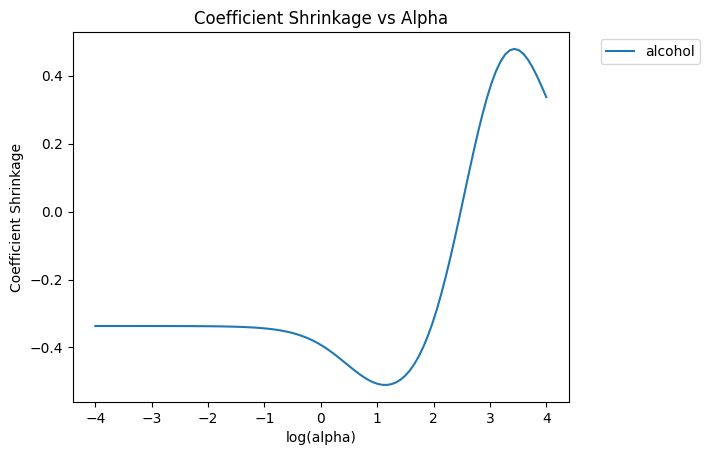

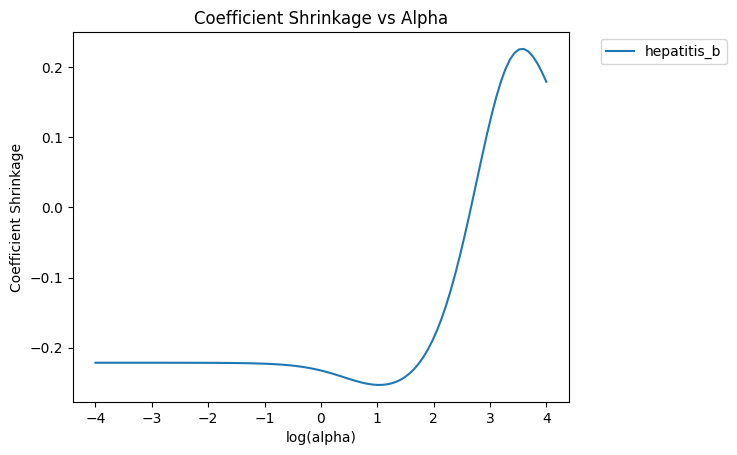

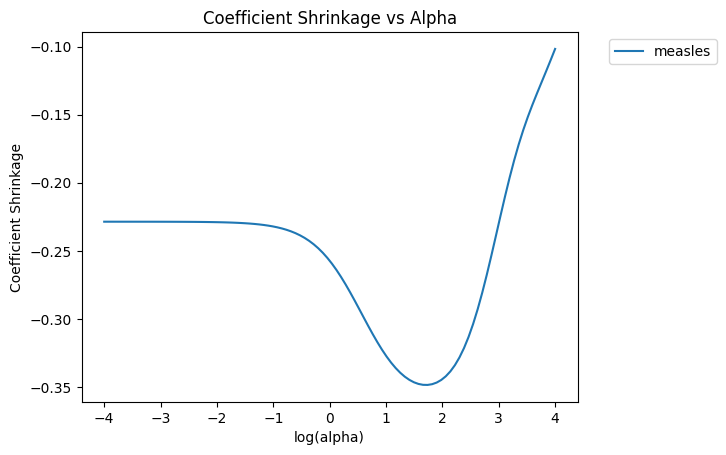

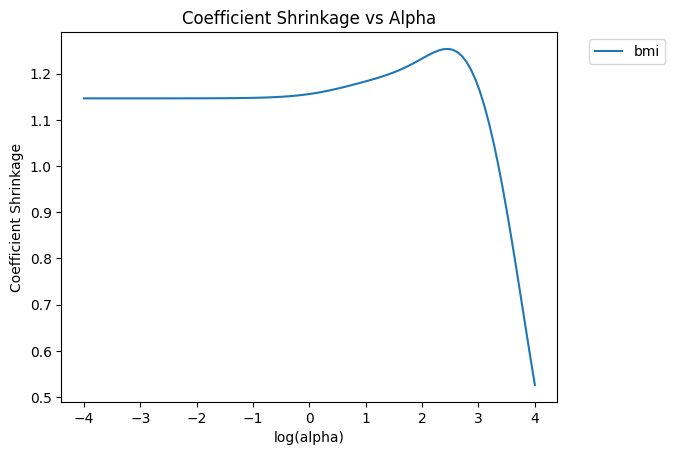

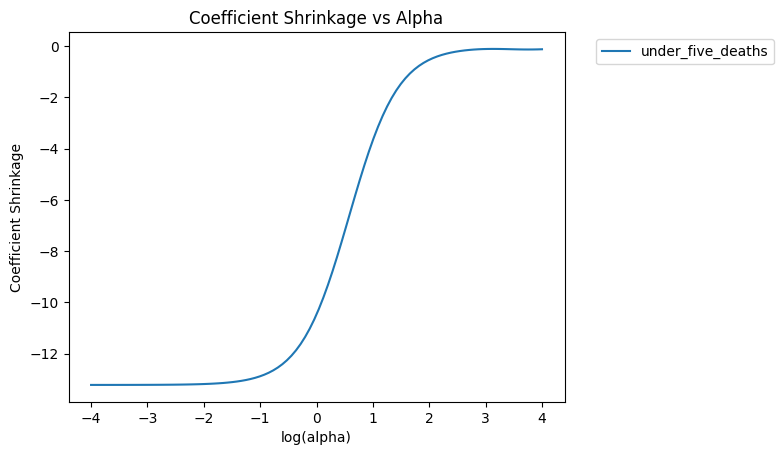

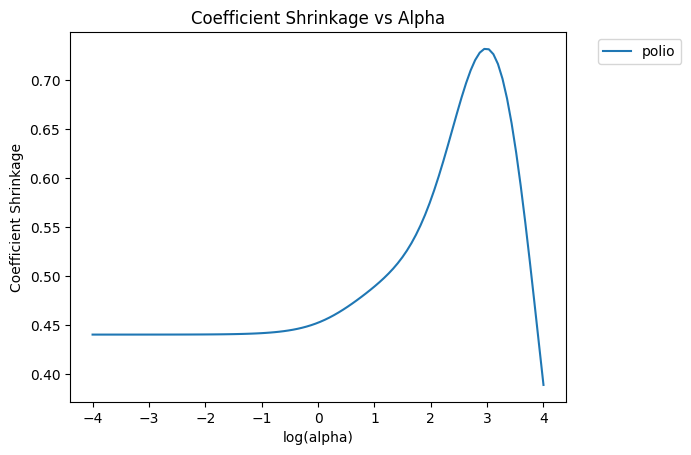

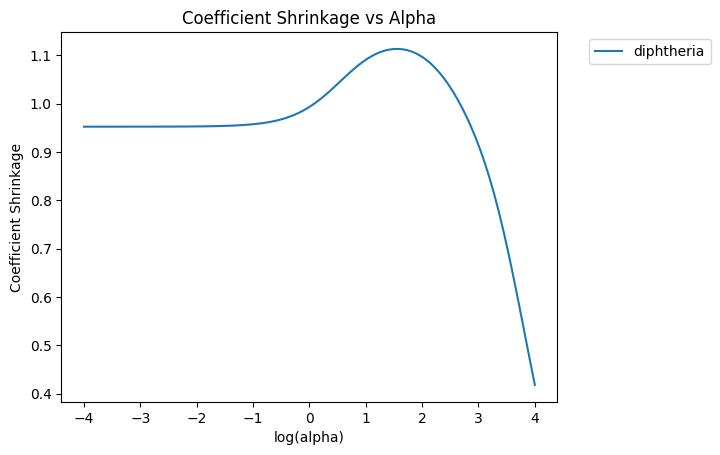

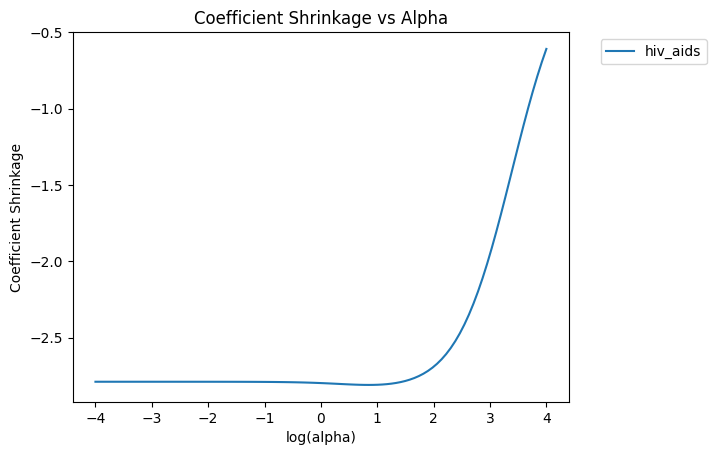

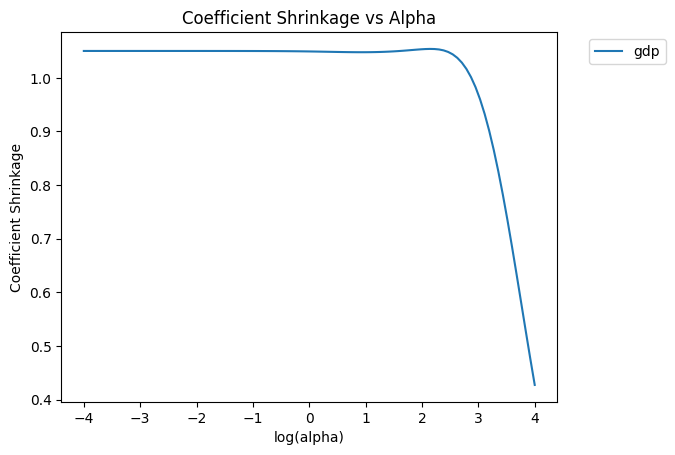

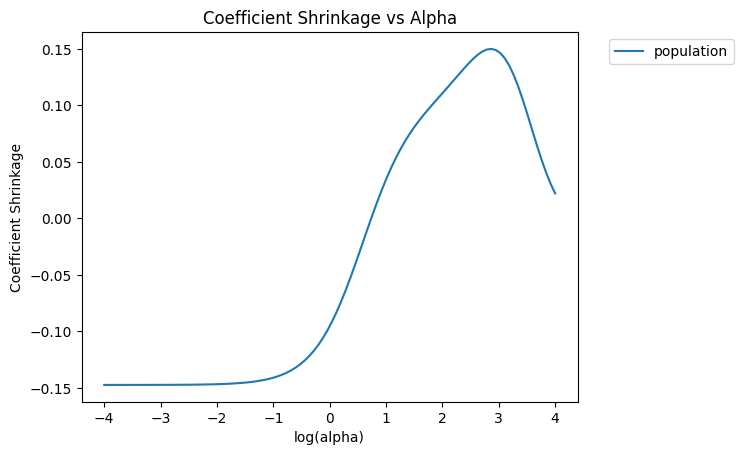

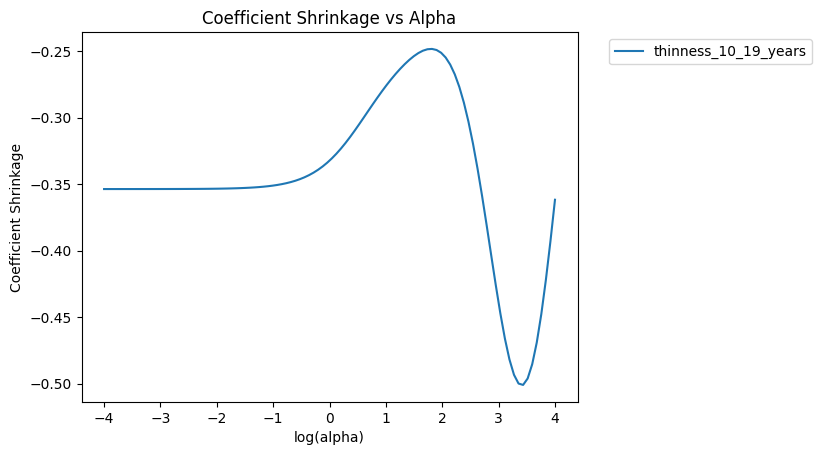

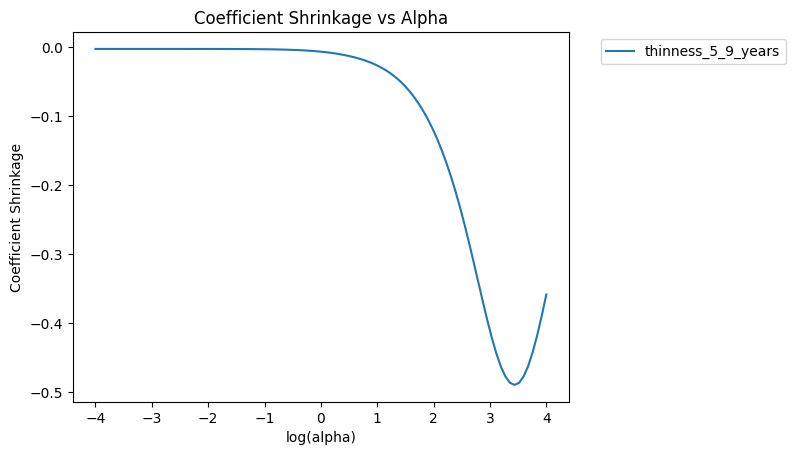

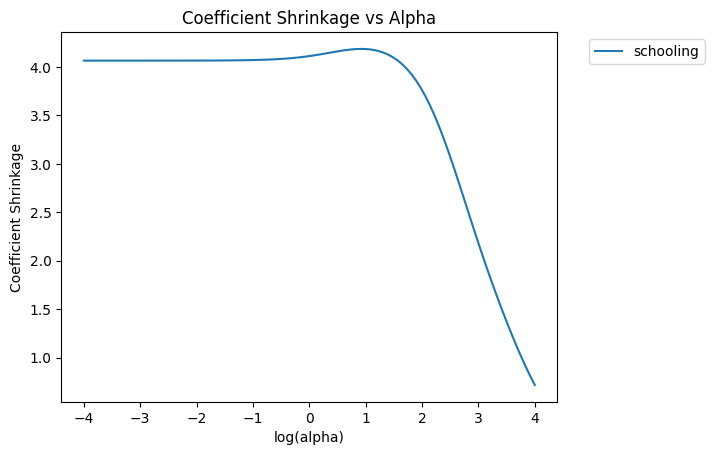

In [ ]:
# Write code here
# model will take numeric values only
train_X_numeric = train_X.select_dtypes(include=[np.number])
test_X_numeric = test_X.select_dtypes(include=[np.number])

#range of alpha values
alphas = np.logspace(-4, 4, 100)

coef_list = []
for alpha in alphas:
  model = make_pipeline(StandardScaler(), Ridge(alpha=alpha))
  model.fit(train_X_numeric, train_y)

  # extracting ridge coefficients only and ignoring scalar
  coef = model.named_steps['ridge'].coef_
  coef_list.append(coef)

coef_array = np.array(coef_list)

# plotting coefficient shrinkage against log(alpha)
plt.figure(figsize=(10, 6))

for i, col in enumerate(train_X_numeric.columns):
  plt.plot(np.log10(alphas), coef_array[:, i], label=col)
  plt.xlabel("log(alpha)")
  plt.ylabel("Coefficient Shrinkage")
  plt.title("Coefficient Shrinkage vs Alpha")
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
  plt.show()

# Report:

We see from plots that **as value of alpha increases the regularization becomes strong and all model weights start shrinking and becoming near to zero**. Shrinkage is smooth and continuous consistent with L2 regularization which penalizes large coefficients but **never set them exactly to zero.**  

We see that l**ess important or highly correlated coefficients tend to approach near to zero more quickly even for moderate values of alpha. Most important coeffients retain large weights and tend to approach towards zero smoothly and slowly**.

Overall the plots show that Ridge stablizes the model by shrinking noisy parameters even if they are highy correlated and presence of multicollinearity. Strong predictirs remain intact.

**Question :** Use sklearn to perform Lasso regression on the data. Evaluate Lasso regression for a range of $\alpha$ values to find the optimal $\alpha$. Report the MSE of the model for the optimal $\alpha$ on the test set.

**Effect of Alpha on Lasso Regression Model:**

AS the value of alpha increase the weights tend to shring towards zero. in Lasso **L1 penalty** is applied, which is: the sum of the absolute values of the model's coefficients, multiplied by a regularization parameter lambda. This **penalty is sdded to cost function which forces some coefficients to tend to exactly zero and ultimately removing them** and selecting features which are strong predictors for the model.

**Lasso regression simplifies the model, reduces overfitting and makes automatic selection of features by keeping only the most relevant features.** This is ideal in case of datasets with large number of features.
When alpha is zero there is no penalty and lasso regression becomes same as ordinary least squares (OLS) regression.

In [ ]:
# Write code here
#sk-learn's lasso model needs numeric input
train_X_numeric = train_X.select_dtypes(include=[np.number])
test_X_numeric = test_X.select_dtypes(include=[np.number])

# define range for lambda values
lambdas = np.logspace(-4, 4, 100)

best_alpha = None
min_mse = float('inf')

for alpha in lambdas:

  lasso_model = make_pipeline(StandardScaler(), Lasso(alpha=alpha, max_iter=5000, random_state=42))


  lasso_model.fit(train_X_numeric, train_y)
  pred_y = lasso_model.predict(test_X_numeric)
  mse = mean_squared_error(test_y, pred_y)

  if mse < min_mse:
    min_mse = mse
    best_alpha = alpha

lasso_rmse = RMSE(test_y, pred_y)
print("\n Optimal Lasso Alpha", best_alpha)

print("\n MSE with Lasso Optimal Alpha: ", min_mse)

print("\n RMSE with Lasso : ", lasso_rmse)

rmse_ols = RMSE(test_y, test_pred_ols)
mse_ols = rmse_ols ** 2
print("\n OLS MSE :",mse_ols )



 Optimal Lasso Alpha 0.000774263682681127

 MSE with Lasso Optimal Alpha:  17.2052031099366

 RMSE with Lasso :  9.664123415391726

 OLS MSE : 17.20556993108671


# Report:
For Lasso regression optimal alpha is 0.000774263682681127 and MSE with optimal alpha is : Alpha:  17.2052031099366. MSE for OLS model shows that model improved in lasso regression. This is because lasso shrinked coefficients and also it eliminated un important coefficients.

**Question :** As the value of $\alpha$ increases, you will notice the the weights of the model parameters will start to change. Plot the values of all the weights against $\log(\alpha$) on a single figure. Describe what you see. It is different from Ridge regression?

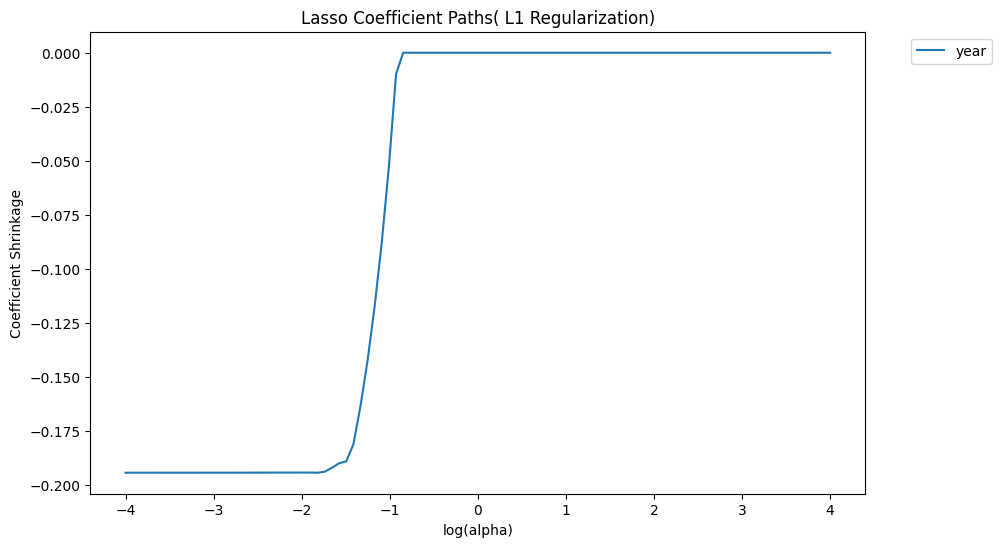

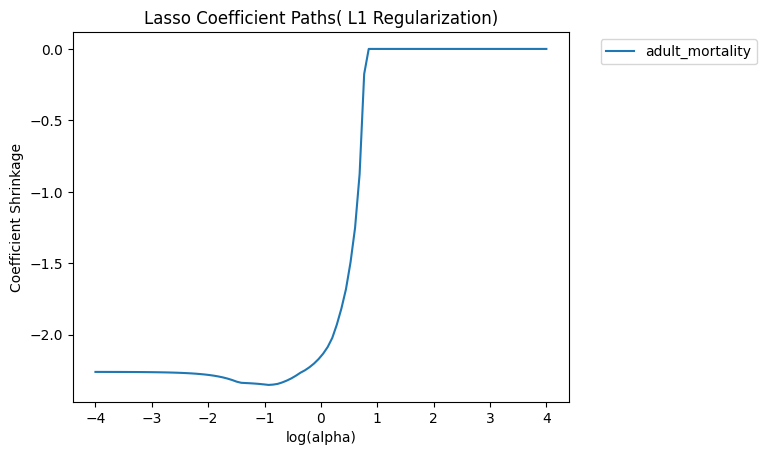

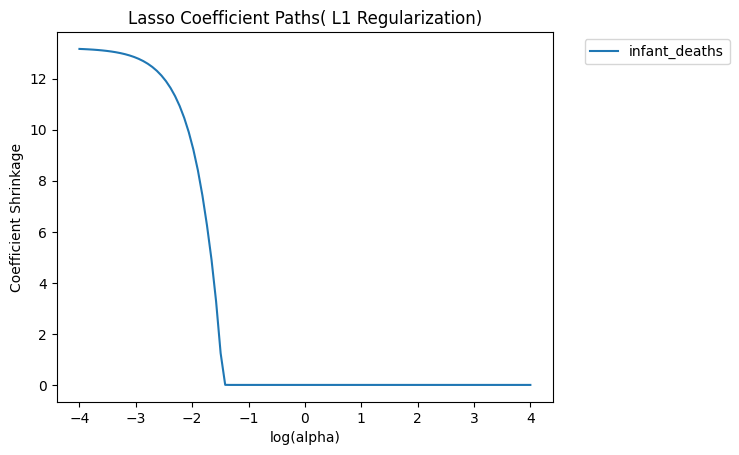

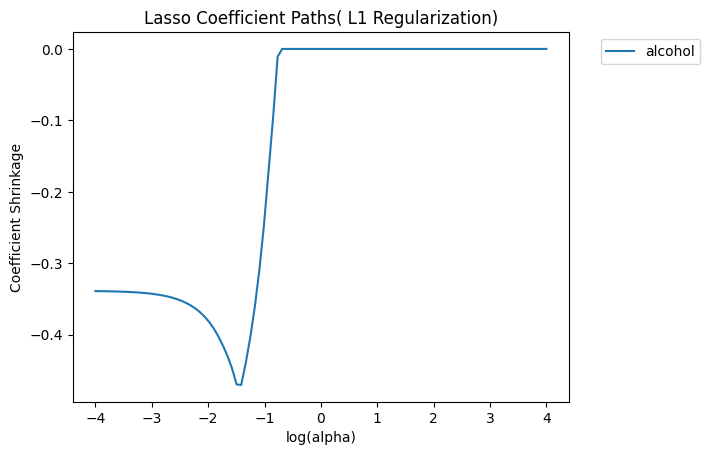

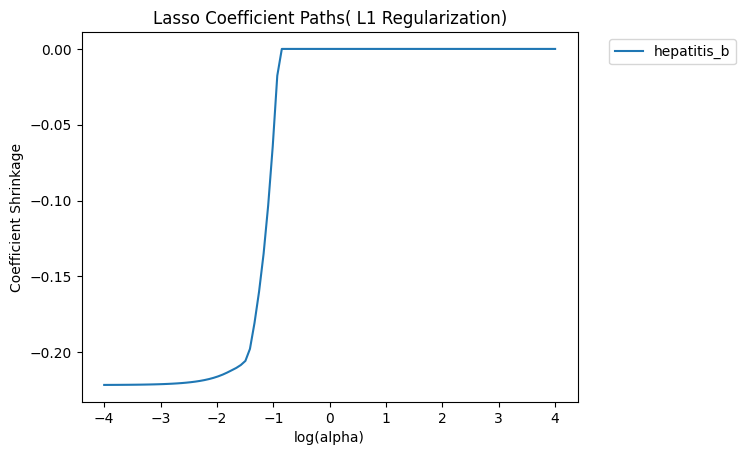

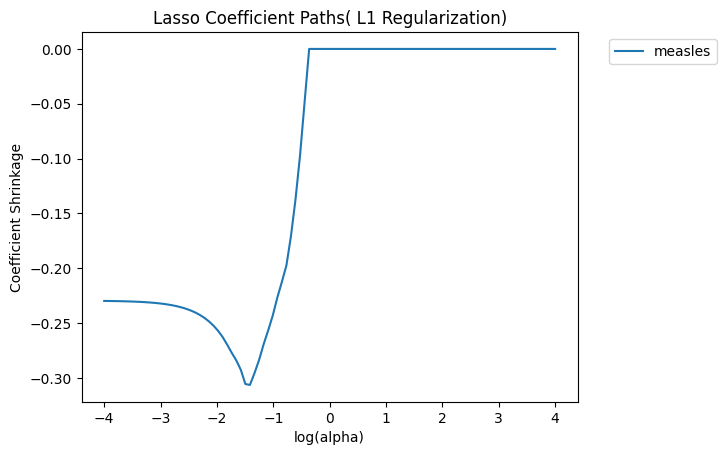

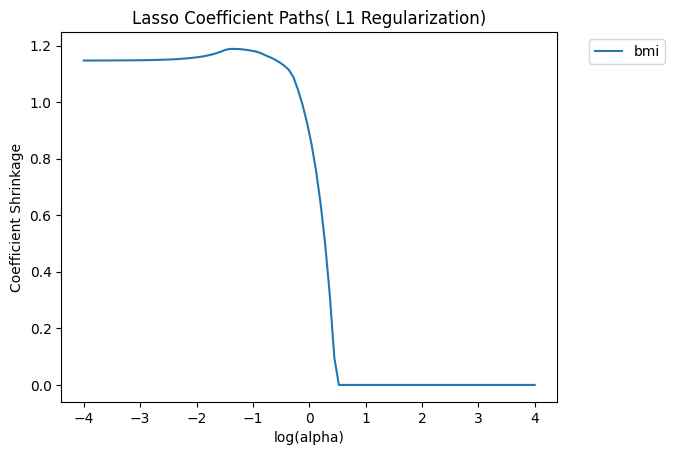

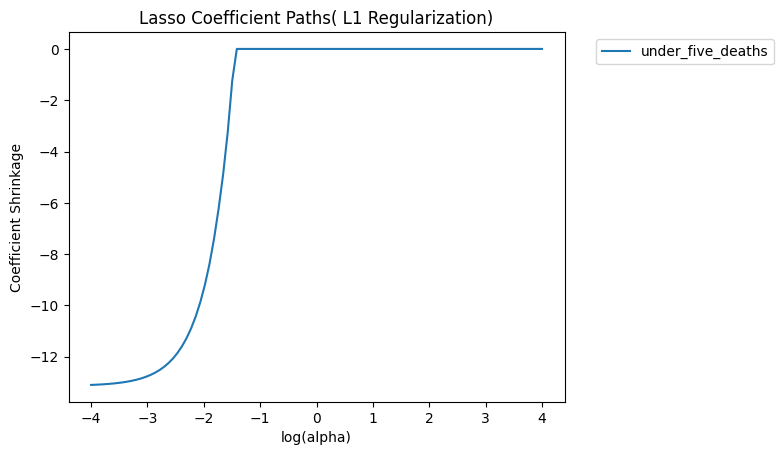

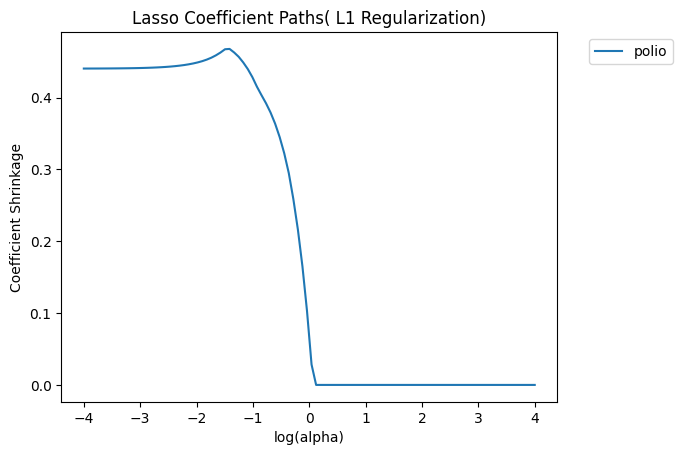

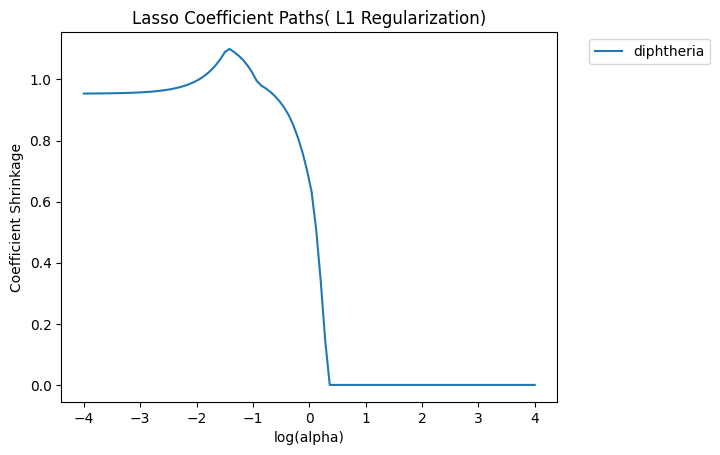

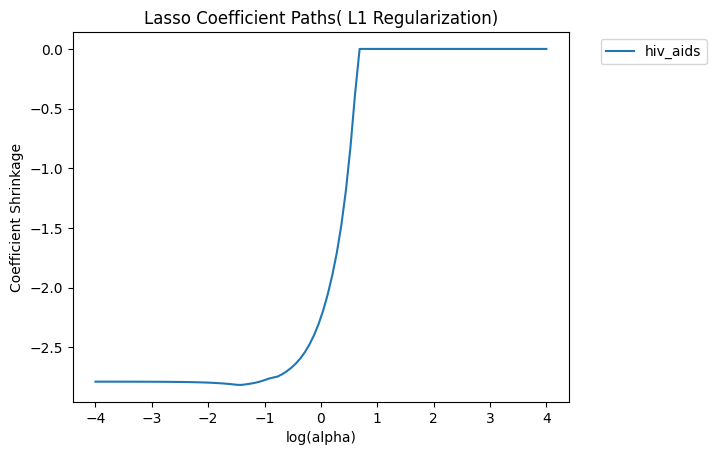

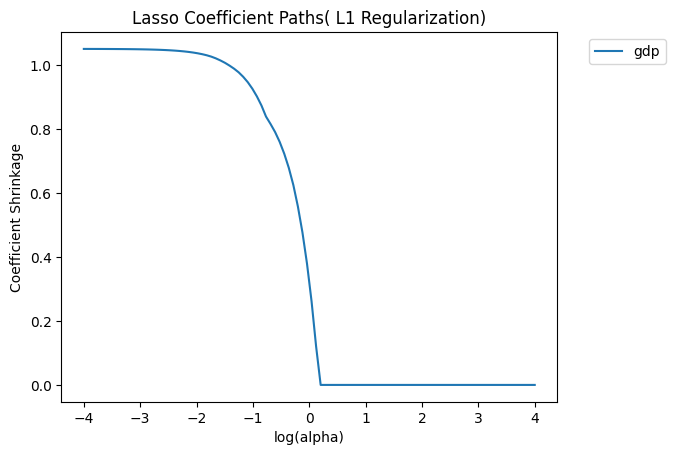

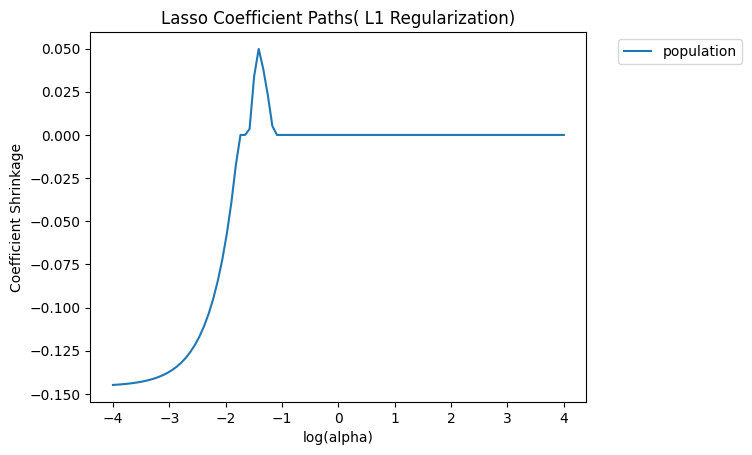

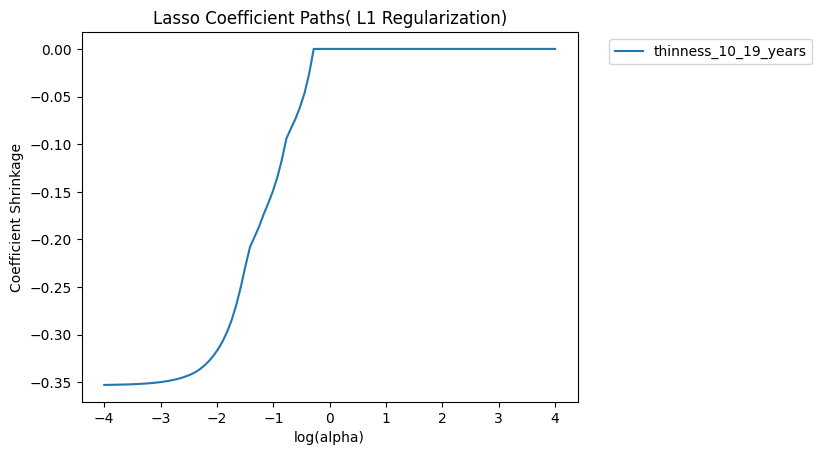

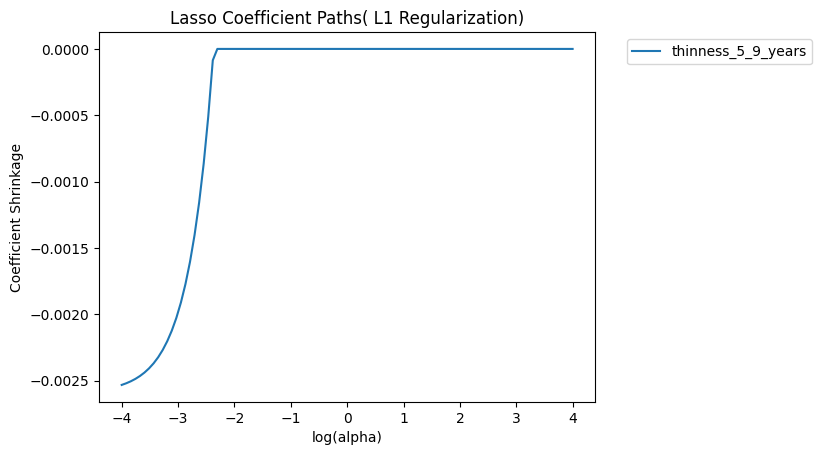

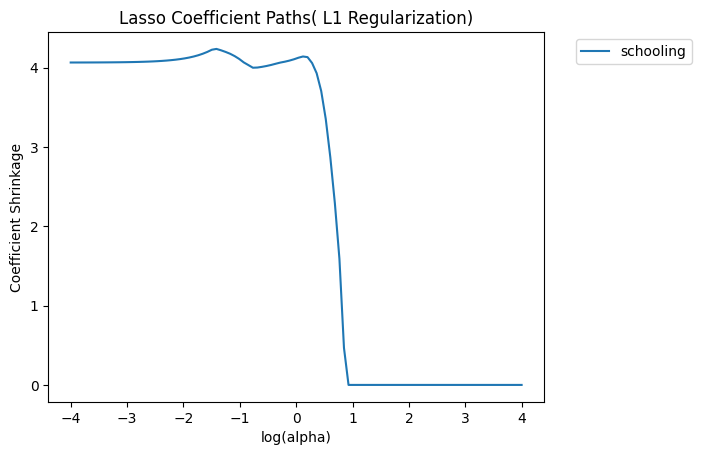

In [ ]:
# Write code here
# lasso model will take numeric values
train_X_numeric = train_X.select_dtypes(include=[np.number])
test_X_numeric = test_X.select_dtypes(include=[np.number])

alphas = np.logspace(-4, 4, 100)

coef_list = []
for alpha in alphas:
  model = make_pipeline(StandardScaler(), Lasso(alpha=alpha))
  model.fit(train_X_numeric, train_y)

  # extracting ridge coefficients only and ignoring scalar
  coef = model.named_steps['lasso'].coef_
  coef_list.append(coef)

coef_array = np.array(coef_list)

# plotting coefficient shrinkage against log(alpha)
plt.figure(figsize=(10, 6))

for i, col in enumerate(train_X_numeric.columns):
  plt.plot(np.log10(alphas), coef_array[:, i], label=col)
  plt.xlabel("log(alpha)")
  plt.ylabel("Coefficient Shrinkage")
  plt.title("Lasso Coefficient Paths( L1 Regularization)")
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
  plt.show()



# Report:

From Lasso coefficients path plots we see as alpha increases the coefficients shrink abruptly to zero. This due to L1 regularization in which coefficients which are less important or highly correlated, shrink to zero. **This is the main difference in Lasso and Ridge regularization that coefficients shrink to zero abruptly in Lasso but not in Ridge. In Ridge coefficients smoothly tend to zero but never reache to zero.** Lasso chooses the features automatically which can help in predictions.

Lasso forces weak coefficients to becomes exactly at zero. **It eliminates coefficients at zero automatically, unlike Ridge**. We can say Lasso does not only regularizes the model but also helps in getting the subset of coefficients which are strong predictors and contribute most in predicting the life expectancy. Strong predictors will remain non zero always. Model eleminates all weak predictors even of they are highy correlated.

# Decision Trees

**Question :** On the same train data, use a decision tree regressor (such as that provided by sklearn). Find the RMSE of the test data on the new predictions generated by your decision tree model. Compare this with your linear model at three values of max_depths: 2, 5, and 10

# Decision Tree Regression:

A tree resgressor or regression tree is **hierarchical tree like structure to predict continous numeric values**. Unlike a claasification tree whuch predicts category or class, a tree regressor outputs a single numerical value at each leaf node level.

**How It Works:**  Core mechanism involves recursively partioning the dataset into smaller more homogeneous subsets. At each internal node the algorithm evaluates all possible slpit points for every feature and selects the one that best minimizes the specific error metric, typically the MSE or variance with in resulting child nodes.

Splitting process continues untill maximum tree depth is obtained, or when no further splits significantly reduce the errors.

**To make a pridictions, we traverse the tree from root to the leaf node by following the decision rules**. The final predicted value is usually the average, mean or median, of the target values of all training samples that ended up in that specific leaf node.

In [ ]:
# Write code here
#using numerical columns only for decision tree
train_X_numeric = train_X.select_dtypes(include=[np.number])
test_X_numeric = test_X.select_dtypes(include=[np.number])

rmse = RMSE(test_y, test_pred)
print("RMSE (OLS Mosdel): ", round(rmse,6))

depths = [2, 5, 10]
for d in depths:
  model = DecisionTreeRegressor(max_depth=d)
  model.fit(train_X_numeric, train_y)
  pred_y = model.predict(test_X_numeric)
  tree_rmse = RMSE(test_y, pred_y)
  print(f"\n Max Depth: {d}, Tree RMSE: {round(tree_rmse,6)}")





RMSE (OLS Mosdel):  4.14796

 Max Depth: 2, Tree RMSE: 5.46193

 Max Depth: 5, Tree RMSE: 3.229445

 Max Depth: 10, Tree RMSE: 2.699014


# Report:
we have RMSE of OLS regression model which is: 4.147.

A shallow tree (max-depth =2) got an RMSE = 5.46193, underfits the linear model.

Tree with (max-depth = 5), captures some non-linear structuremay get closer to or slightly better than linear RMSE.

Tree with (max-depth = 10) gets RMSE = 2.715833, overfits the model, which can increase the test RMSE again.

# Random Forests

**Question :** A sklearn random forest model has variable number of estimators and maximum depth of trees. Selecting suitable ranges for both parameters, plot a 3D plot of the RMSE against both of these parameters. What do you see? For the optimal values of these parameters report the RMSE on the test data.



Best parameters:
  max_depth    = 4
  n_estimators = 200
  RMSE         = 2.229082


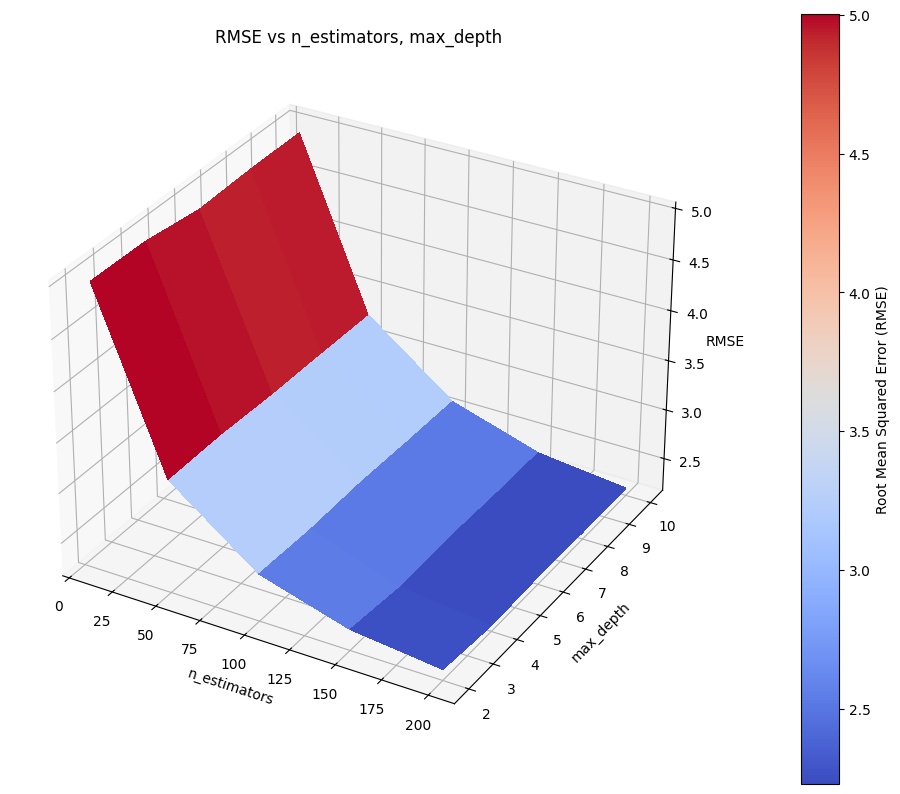

In [ ]:
# code here
train_X_numeric = train_X.select_dtypes(include=[np.number])
test_X_numeric = test_X.select_dtypes(include=[np.number])

n_estimators = [10, 50, 100, 150,200]
max_depths = [2, 4, 6, 8, 10]

rmse_matrix = np.zeros((len(n_estimators), len(max_depths)))

for i, depth in enumerate(max_depths):
  for j, estimator in enumerate(n_estimators):
    rf = RandomForestRegressor(n_estimators=estimator, max_depth=depth, random_state=42, n_jobs=-1)
    rf.fit(train_X_numeric, train_y)
    pred_y = rf.predict(test_X_numeric)
    rmse_matrix[j, i] = RMSE(test_y, pred_y)
    #print(f"Max Depth: {depth}, n_estimators: {estimator}, RMSE: {rmse_matrix[j, i]}")

#finding optimal parameters and their RMSE
min_idx = np.unravel_index(np.argmin(rmse_matrix), rmse_matrix.shape)
best_depth = max_depths[min_idx[0]]
best_n_est = n_estimators[min_idx[1]]
best_rmse  = rmse_matrix[min_idx]

print("\nBest parameters:")
print("  max_depth    =", best_depth)
print("  n_estimators =", best_n_est)
print("  RMSE         =", round(best_rmse, 6))

# Plot 3D Surface RMSE vs n_estimators, max_depth
from matplotlib import cm
N, D = np.meshgrid(n_estimators, max_depths)

fig = plt.figure(figsize = (12,10))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(N, D, rmse_matrix, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)

m = cm.ScalarMappable(cmap=cm.coolwarm)
m.set_array(rmse_matrix) # Use your Z-data matrix
fig.colorbar(m, ax=ax, pad=0.1, label='Root Mean Squared Error (RMSE)')

ax.set_xlabel('n_estimators')
ax.set_ylabel('max_depth')
ax.set_zlabel('RMSE')
plt.title('RMSE vs n_estimators, max_depth')
plt.show()


# Report:

We see from 3-D plot that:

Dark Blue colour representing lowest RMSE values. Best performance with lowest erorrs. Light blue coloures mean middle range RMSE values, the divergence point. Dark red coloure mean highest RMSE values which means worst performance with highest errors. Valleys, the areas colored deep blue indicate combinations of N and D which resulted in best performance with lowest errors. Peeks, red colored areas indicate combinations of N and D the resulted in the worst model performance with highest errors.

RMSE decreases as n_estimators increase. Its at least initially then then improves the performance at certain level but the gains dimish after a certain point.

RMSE decreases as max_depth increases upto a point. Its for the reason that, deeper trees capture more complexity and non-linear patterns.

Beyond some depth the test RMSE may faltten out or or slightly increase due to overfitting even though training errors keep on decreasing.

The surface usually has a valley with high RMSE with shallow trees or very few estimators. Lower RMSE at the middle. sometimes slightly worse again for very deep trees. **This suggest that too shallow trees underfit, while very deep trees offer additional generalization benefit.**

As final result Random Forest Model performs better as compared to earlier linear and regularized models confirming that non linear models can caputre additional structure in our given life expectancy dataset  




#**Question :**# There are other hyperparameters in a random forest model. Play with them to find values that give a lower RMSE on the test data than what you found above. There is no fixed method for this so you are free to use and adapt any hyperparameter.

# Hyperparameters in Random Forest Model:

There **two main categories** of hyper parameters in random forest model. Those that **control the individual decision tree** and the one that **controls ensemble properties**. We will be using parameters, n_estimators, max_depth, min_samples_split, min samples_leaf, max_features, bootstrap.

**n_estimator**s represent the number of trees in the forest. Generally more trees improve performance and stability by reducing variance.

**max_depth** is the maximum number of levels a tree is allowed to grow. We can overcome overfitting by limiting the number of levels.

**min_samples_split** is minimum number of samples required to be present at node level so that it should be considered for splitting.

**min_samples-leaf** is the minimum number of samples that must be present at leaf node level after splitting. The higher number represents less noise and more generalized model.

**max_features** is the number of features considered to be ideal for splitting at each node. for classification model its square root(sqrt) of total features and for regression its all features or fraction.

**bootstrap** is a core technique used in ensemble methods. Its a resampling method with replacement. From a training dataset N size sample is taken, again same size sample is taken from same sample by randomly selecting the observations. This allows the same datapoint to be selected several times and may be leaving other completely. If its value is true this introduces diversity among trees, reduces the variance and controls the overfitting.

In [ ]:
# Write code here
hyper_params = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

rf_regressor = RandomForestRegressor(random_state=42, n_jobs=-1)

rf_random = RandomizedSearchCV(estimator=rf_regressor, param_distributions=hyper_params,
                               n_iter=30, cv = 3, scoring='neg_mean_squared_error',
                               verbose=2, random_state=42,n_jobs=-1)

rf_random.fit(train_X_numeric, train_y)

print("Best Hyper Parameters: ",rf_random.best_params_)

# evaluating best RF on the test test and comparing the RMSE

best_rf = rf_random.best_estimator_

pred_y = best_rf.predict(test_X_numeric)

mse_best_rf = mean_squared_error(test_y, pred_y)

rsme_best_rf = np.sqrt(mse_best_rf)
print("\n Best RF MSE: ", round(mse_best_rf,6))

print("\n Best RF RMSE: ", round(rsme_best_rf,6))

rmse_ols = RMSE(test_y, test_pred)
print("\n RMSE OLS ",round(rmse_ols,6))

print("\n Ridge RMSE : ", round(ridge_rmse,6))

print("\n Lasso RMSE : ", round(lasso_rmse,6))

print("\n Tree RMSE : ", round(tree_rmse,6))


Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best Hyper Parameters:  {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20, 'bootstrap': False}

 Best RF MSE:  4.180332

 Best RF RMSE:  2.044586

 RMSE OLS 4.14796

 Ridge RMSE :  4.14796

 Lasso RMSE :  9.664123

 Tree RMSE :  2.699014


# Report:

WE can see that after fine tunning the additional hyper parameters in random forest model we obtained **RMSE 2.044586**. Hyper parameter's list is also printed which are n_estimators, min_sample_split, min_sample_leaf, max_features, log2, max_depth, bootstrap. RMSE obtained from random forest model is clearly less than RMSE obtained from OLS, Ridge, Lasoo and Tree regression models.

We can deduct that **controlling tree complexity and the number of features considered at each split improves generalization and reduces overfitting at given dataset**.

We can also deduct that allowing more trees like 300 as in our dataset gives small but stable gain.

Letting trees be deeper (max_width = none) but using min_sample_split and min_sample_leaf to regularize, gives better outcome.

Setting max_features = sqrt improves the performance as compared to using all the features.


# Open-ended Research Question

**Question :** A large part of machine learning is about using prior domain knowledge or doing research/exploration to find a model that suits your dataset. This could also involve adjusting hyperparameters, doing feature engineering, or using a new approach altogether.

Your final task is to find a model that has the lowest RMSE across **all** the following train-test split ratios (on the provided dataset).

1. 90% Train, 10% Test
2. 70% Train, 30% Test
3. 50% Train, 50% Test
4. 30% Train, 70% Test

For this part, you can only use the following five model types: OLS, Ridge, Lasso, Decision Tree, or a Random Forest Model. You are free to tune the hyperparameters or do feature engineering.

For output purposes, fit suitable instances of all the model types on your training data and print the RMSE (of the test data) across the four train-test splits seperately.

In [ ]:

# declaring features and target variabe
X_all = df.drop('life_expectancy', axis=1)
y = df['life_expectancy']
# choosing number columns only
X = X_all.select_dtypes(include=[np.number])

#print("X shape:", X.shape)
#print("y shape:", y.shape)

# choosing splits
splits = {
    "90% Train / 10% Test": 0.10,
    "70% Train / 30% Test": 0.30,
    "50% Train / 50% Test": 0.50,
    "30% Train / 70% Test": 0.70
}

# five models to work on
models = {
    "OLS": Pipeline([
        ("scaler", StandardScaler()),
        ("reg", LinearRegression())
    ]),
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("reg", Ridge())
    ]),
    "Lasso": Pipeline([
        ("scaler", StandardScaler()),
        ("reg", Lasso(max_iter=10000))
    ]),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42, n_jobs=-1),
}
# parameters distribution
param_distributions = {
    "OLS": {},  # no hyperparameters to tune

    "Ridge": {
        "reg__alpha": uniform(0.0001, 10.0),
    },

    "Lasso": {
        "reg__alpha": uniform(0.0001, 1.0),
    },

    "Decision Tree": {
        "max_depth": randint(2, 20),
        "min_samples_split": randint(2, 20),
        "min_samples_leaf": randint(1, 10),
    },

    "Random Forest": {
        "n_estimators": randint(50, 300),
        "max_depth": randint(2, 20),
        "min_samples_split": randint(2, 20),
        "min_samples_leaf": randint(1, 10),
    },
}

def RMSE(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# loop to tune models

results_rmse = {model_name: {} for model_name in models}
best_params_all = {split_name: {} for split_name in splits}

for split_name, test_size in splits.items():
    print(f"\n================= {split_name} (test_size={test_size}) =================")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    print("  X_train shape:", X_train.shape, " | y_train shape:", y_train.shape)

    for model_name, base_model in models.items():
        print(f"\n -> Running {model_name}")

        # no hyperparameters to tune (OLS)
        if not param_distributions[model_name]:
            best_model = base_model.fit(X_train, y_train)

        # RandomizedSearchCV for hyperparameter tuning
        else:
            rsearch = RandomizedSearchCV(
                estimator=base_model,
                param_distributions=param_distributions[model_name],
                n_iter=20,
                cv=3,
                scoring='neg_mean_squared_error',
                random_state=42,
                n_jobs=-1
            )

            rsearch.fit(X_train, y_train)

            best_model = rsearch.best_estimator_

            best_params_all[split_name][model_name] = rsearch.best_params_

            print("   Best Params:", rsearch.best_params_)

        # Evaluate on test set for this split
        y_pred = best_model.predict(X_test)
        rmse = RMSE(y_test, y_pred)
        results_rmse[model_name][split_name] = rmse

        print(f"   Test RMSE: {rmse:.4f}")


rmse_df = pd.DataFrame(results_rmse).T

print("\n\n================= RMSE TABLE (rows: models, cols: splits) =================\n")
print(rmse_df)

print("\nBest (lowest RMSE) model for each split:")
print(rmse_df.idxmin(axis=0))

print("\nAverage RMSE across all four splits for each model:")
avg_rmse = rmse_df.mean(axis=1)
print(avg_rmse.sort_values())



================= 90% Train / 10% Test (test_size=0.1) =================
  X_train shape: (1916, 16)  | y_train shape: (1916,)

 -> Running OLS
   Test RMSE: 4.0762

 -> Running Ridge
   Best Params: {'reg__alpha': np.float64(0.20594494295802446)}
   Test RMSE: 4.0770

 -> Running Lasso
   Best Params: {'reg__alpha': np.float64(0.020684494295802446)}
   Test RMSE: 4.1262

 -> Running Decision Tree
   Best Params: {'max_depth': 13, 'min_samples_leaf': 2, 'min_samples_split': 11}
   Test RMSE: 3.1407

 -> Running Random Forest
   Best Params: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 99}
   Test RMSE: 2.0300

================= 70% Train / 30% Test (test_size=0.3) =================
  X_train shape: (1490, 16)  | y_train shape: (1490,)

 -> Running OLS
   Test RMSE: 4.1480

 -> Running Ridge
   Best Params: {'reg__alpha': np.float64(0.20594494295802446)}
   Test RMSE: 4.1484

 -> Running Lasso
   Best Params: {'reg__alpha': np.float64(0.0206844942958

# Report:

We tuned our models to get best hyperparameters and RMSE.

Models used are: OLS, Ridge, Lasso, Decision Tree, Random Forest.

Splits set is: 90% Train, 10% Test
70% Train, 30% Test
50% Train, 50% Test
30% Train, 70% Test

When:
 Running OLS
   Test RMSE: 4.0762

 -> Running Ridge
   Best Params: {'reg__alpha': np.float64(0.20594494295802446)}
   Test RMSE: 4.0770

 -> Running Lasso
   Best Params: {'reg__alpha': np.float64(0.020684494295802446)}
   Test RMSE: 4.1262

 -> Running Decision Tree
   Best Params: {'max_depth': 13, 'min_samples_leaf': 2, 'min_samples_split': 11}
   Test RMSE: 3.1407

 -> Running Random Forest
   Best Params: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 99}
   Test RMSE: 2.0300

After getting all sets pf best parameters and RMSE, we can conclude that **90% Train, 10% Test split is the best**. This split provides a large volume of data for the model to learn from. It leads to more robust and accurate model. This allows to better identify underlying patterns, relationships and nuances in the data. This hepls in improving predictibility and reducing the underfitting. It provides better generaliztion and higher accuracy. This split is frequently used in conjunction with techniques like k-fold cross validation, where entire dataset is used for both training across different folds and testing, providing over all more reliable performance estimate.


Average RMSE across all four splits for each model:

Random Forest    2.217962

Decision Tree    2.967938

OLS              4.117021

Ridge            4.117153

Lasso            4.197582

These values indicating that *90% Train, 10% Test split is the best and in  models Random forest model is better for current dataset.
  
